# Baby Shopper Profiling — Phase 1
## Behavioral & Temporal Shopper Intelligence

**Objective:** Establish a data-driven, time-aware understanding of how baby shoppers behave — grounded entirely in observed transaction data.

**Scope (Phase 1):**
- Temporal behavioral features: frequency, cadence, burst, activity span, recency
- Spend-based profiling
- Category journey signals
- Behavioral clustering

**Data:** `combined_shoppers.parquet`
- 8.3M rows | 7 columns
- Columns: `gcr_persistent_id`, `header_tran_date`, `department_cleaned`, `subdepartment_cleaned`, `subclass`, `total_sales`, `total_units`

**Phase 2 (out of scope here):** Predictive modeling, lifecycle transition detection


---
## 1. Setup & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ── Visual theme ───────────────────────────────────────────────────────────────
PALETTE = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#762A83', '#F46D43']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 12,
                     'axes.titleweight': 'bold', 'figure.titlesize': 13})
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Constants ──────────────────────────────────────────────────────────────────
BURST_WINDOW_DAYS  = 7     # transactions within N days = burst cluster
BULK_PERCENTILE    = 0.90  # upper decile of daily units = bulk purchase day
OBSERVATION_MONTHS = 12    # rolling observation window
RANDOM_STATE       = 42

print("Setup complete.")


Setup complete.


---
## 2. Data Loading & Cleaning

In [ ]:
raw = pd.read_parquet(r"C:\Users\dacdatalabs.ojt2\Desktop\workspace\DS\datasets\combined_shoppers.parquet")
print(f"Raw shape: {raw.shape}")
print(f"Columns: {list(raw.columns)}")
raw.head(3)

Raw shape: (8320948, 7)
Columns: ['gcr_persistent_id', 'header_tran_date', 'department_cleaned', 'subdepartment_cleaned', 'subclass', 'total_sales', 'total_units']


,gcr_persistent_id,header_tran_date,department_cleaned,subdepartment_cleaned,subclass,total_sales,total_units
0,id-2024042312270501717852-01-irz7p-bkor-uul9-g...,13 Apr 2025,Babies' Wear,Newborn Essential 0-12 Mos,Md Promo,280.000,1
1,id-20240423122704961961115-01-8y9mw-jxx6-dohu-...,4 Apr 2025,Babies' Wear,Newborn Essential 0-12 Mos,Md Promo,510.000,2
2,id-20240423122706217217036-01-bp1ai-zbqq-466i-...,19 Apr 2025,Babies Accs & Furn,Nursing & Feeding,Sc Nursing Supplies & Acc,159.000,1


In [5]:
# ── 2.1 Normalise text fields ─────────────────────────────────────────────────
for col in ['department_cleaned', 'subdepartment_cleaned', 'subclass']:
    raw[col] = raw[col].str.lower().str.strip()

# ── 2.2 Parse dates ───────────────────────────────────────────────────────────
raw['date'] = pd.to_datetime(raw['header_tran_date'], format='%d %b %Y', errors='coerce')
n_bad = raw['date'].isna().sum()
print(f"Unparseable dates: {n_bad:,}")
raw = raw.dropna(subset=['date', 'gcr_persistent_id'])

# ── 2.3 Remove promotional / clearance rows ───────────────────────────────────
PROMO_FILTERS = [
    ('subclass',              'md promo'),
    ('subdepartment_cleaned', 'iw promotions'),
    ('subdepartment_cleaned', 'iaf clearance'),
    ('subdepartment_cleaned', 'iaf promotions'),
]
before = len(raw)
for col, val in PROMO_FILTERS:
    raw = raw[raw[col] != val]
print(f"Removed {before - len(raw):,} promo/clearance rows")

# ── 2.4 Observation window ────────────────────────────────────────────────────
SNAPSHOT_DATE = raw['date'].max()
WINDOW_START  = SNAPSHOT_DATE - pd.DateOffset(months=OBSERVATION_MONTHS)
df = raw[raw['date'] >= WINDOW_START].copy()

print(f"\nObservation window : {WINDOW_START.date()} → {SNAPSHOT_DATE.date()}")
print(f"Rows in window     : {len(df):,}")
print(f"Unique customers   : {df['gcr_persistent_id'].nunique():,}")
print(f"Unique subdepts    : {df['subdepartment_cleaned'].nunique()}")


Unparseable dates: 549,869
Removed 610,960 promo/clearance rows

Observation window : 2024-12-31 → 2025-12-31
Rows in window     : 7,160,119
Unique customers   : 1,429,702
Unique subdepts    : 26


In [6]:
# ── 2.5 Subdepartment overview ────────────────────────────────────────────────
subdept_summary = (
    df.groupby('subdepartment_cleaned')
      .agg(rows=('date','count'), customers=('gcr_persistent_id','nunique'),
           total_units=('total_units','sum'), total_sales=('total_sales','sum'))
      .sort_values('customers', ascending=False)
)
print("Top subdepartments by customer count:")
subdept_summary.head(15)


Top subdepartments by customer count:


,rows,customers,total_units,total_sales
subdepartment_cleaned,,,,
newborn essential 0-12 mos,1246184,425895,1785643,708940837.510
toiletries,1405766,420662,2287376,484253651.480
nursing & feeding,1011332,398007,1317768,700456578.570
infant shoes,357330,255000,400428,204365304.540
toddler boys casual,469557,246800,634163,353263944.030
baby girl fashion 0-24 mos,379433,235315,483467,171085409.930
toddler girls casual apparel,343642,188980,480096,236061501.740
baby c + o,298217,183784,476175,112157310.640
personal care,213439,134399,232214,94783975.180


In [7]:
# ── 2.6 Encode customer ID (integer for speed) ────────────────────────────────
df['customer_id'] = pd.factorize(df['gcr_persistent_id'])[0]
df['year_month']  = df['date'].dt.to_period('M')
df = df.sort_values(['customer_id', 'date']).reset_index(drop=True)

print(f"Final working dataset: {df.shape}")


Final working dataset: (7160119, 10)


---
## 3. Longitudinal Panel — Customer × Month

A **balanced panel** ensures every customer appears in every month of the observation window — including months with zero activity. This eliminates missing-time bias and enables consistent computation of month-over-month deltas.

> All customers are included regardless of history length, as per project scope.


In [8]:
# ── 3.1 Aggregate to customer × day first (needed for burst later) ────────────
daily = (
    df.groupby(['customer_id', 'date'])
      .agg(
          day_transactions = ('date',         'count'),
          day_units        = ('total_units',  'sum'),
          day_sales        = ('total_sales',  'sum'),
          distinct_subdepts_day = ('subdepartment_cleaned', 'nunique'),
      )
      .reset_index()
)
daily['year_month'] = daily['date'].dt.to_period('M')

# ── 3.2 Aggregate daily → monthly ────────────────────────────────────────────
monthly_raw = (
    daily.groupby(['customer_id', 'year_month'])
         .agg(
             total_transactions   = ('day_transactions',     'sum'),
             total_units          = ('day_units',            'sum'),
             total_spend          = ('day_sales',            'sum'),
             days_active_in_month = ('date',                 'count'),
             last_purchase_date   = ('date',                 'max'),
             distinct_subdept_count = ('distinct_subdepts_day', 'max'),
         )
         .reset_index()
)

# ── 3.3 Build balanced grid ───────────────────────────────────────────────────
all_months    = pd.period_range(df['year_month'].min(), df['year_month'].max(), freq='M')
all_customers = df['customer_id'].unique()

panel_index = pd.MultiIndex.from_product(
    [all_customers, all_months], names=['customer_id', 'year_month']
)
panel = pd.DataFrame(index=panel_index).reset_index()
panel = panel.merge(monthly_raw, on=['customer_id','year_month'], how='left')

fill_zero = ['total_transactions','total_units','total_spend',
             'days_active_in_month','distinct_subdept_count']
panel[fill_zero] = panel[fill_zero].fillna(0)
panel['is_active'] = (panel['total_transactions'] > 0).astype(int)

print(f"Balanced panel: {panel.shape[0]:,} rows | "
      f"{len(all_customers):,} customers × {len(all_months)} months")
panel.head(8)


Balanced panel: 17,156,424 rows | 1,429,702 customers × 12 months


,customer_id,year_month,total_transactions,total_units,total_spend,days_active_in_month,last_purchase_date,distinct_subdept_count,is_active
0,0,2025-01,0.000,0.000,0.000,0.000,NaT,0.000,0
1,0,2025-02,0.000,0.000,0.000,0.000,NaT,0.000,0
2,0,2025-03,0.000,0.000,0.000,0.000,NaT,0.000,0
3,0,2025-04,1.000,1.000,159.000,1.000,2025-04-19,1.000,1
4,0,2025-05,0.000,0.000,0.000,0.000,NaT,0.000,0
5,0,2025-06,0.000,0.000,0.000,0.000,NaT,0.000,0
6,0,2025-07,0.000,0.000,0.000,0.000,NaT,0.000,0
7,0,2025-08,0.000,0.000,0.000,0.000,NaT,0.000,0


---
## 4. Temporal Behavioral Features

Building the **temporal signature** for each shopper across five dimensions:
1. Purchase cadence (inter-purchase gaps)
2. Early engagement speed
3. Activity span
4. Behavioral rhythm (regular vs clustered)
5. Recency


In [9]:
# ── 4.1 Inter-purchase gap (day-level) ────────────────────────────────────────
# Use daily aggregation — one row per customer-day they were active
active_days = (
    daily[['customer_id','date']].drop_duplicates()
         .sort_values(['customer_id','date'])
)
active_days['gap_days'] = (
    active_days.groupby('customer_id')['date'].diff().dt.days
)

gap_stats = (
    active_days.groupby('customer_id')['gap_days']
               .agg(
                   avg_gap_days    = 'mean',
                   median_gap_days = 'median',
                   std_gap_days    = 'std',
                   min_gap_days    = 'min',
                   max_gap_days    = 'max',
               )
               .reset_index()
)
# Purchase regularity: coefficient of variation (lower = more regular)
gap_stats['purchase_regularity_cv'] = (
    gap_stats['std_gap_days'] / gap_stats['avg_gap_days'].clip(lower=0.01)
)

print("Gap statistics sample:")
gap_stats.head()


Gap statistics sample:


,customer_id,avg_gap_days,median_gap_days,std_gap_days,min_gap_days,max_gap_days,purchase_regularity_cv
0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,58.000,45.500,63.008,6.000,135.000,1.086
2,2,114.500,114.500,136.472,18.000,211.000,1.192
3,3,49.500,49.500,41.719,20.000,79.000,0.843
4,4,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# ── 4.2 Activity span & engagement timeline ───────────────────────────────────
span = (
    df.groupby('customer_id')['date']
      .agg(first_purchase=('min'), last_purchase=('max'), total_purchase_days=('nunique'))
      .reset_index()
)
span['activity_span_days'] = (span['last_purchase'] - span['first_purchase']).dt.days
span['days_since_last_purchase'] = (SNAPSHOT_DATE - span['last_purchase']).dt.days

# Active months (months with ≥1 transaction)
active_months = (
    panel[panel['is_active']==1]
         .groupby('customer_id')['year_month']
         .nunique()
         .rename('active_months')
         .reset_index()
)

span = span.merge(active_months, on='customer_id', how='left')
span['active_months'] = span['active_months'].fillna(1)

# Engagement density: active months / possible months
n_months = len(all_months)
span['engagement_density'] = span['active_months'] / n_months

print("Activity span sample:")
span[['customer_id','activity_span_days','active_months',
      'days_since_last_purchase','engagement_density']].head()


Activity span sample:


,customer_id,activity_span_days,active_months,days_since_last_purchase,engagement_density
0,0,0,1,256,0.083
1,1,232,4,17,0.333
2,2,229,3,23,0.250
3,3,99,2,254,0.167
4,4,0,1,272,0.083


In [11]:
# ── 4.3 Early engagement speed ────────────────────────────────────────────────
# Days from first purchase to second purchase — signals intent to return
# Vectorised: sort by date, keep only the first 2 shopping days per customer
active_days_sorted = active_days.sort_values(['customer_id', 'date'])
active_days_sorted['_rn'] = active_days_sorted.groupby('customer_id').cumcount()
first_two = active_days_sorted[active_days_sorted['_rn'] <= 1].drop(columns='_rn')

# gap_days on row 1 of each customer = days from 1st to 2nd purchase
first_two_gap = (
    first_two[first_two.groupby('customer_id')['date'].transform('count') > 1]
    .groupby('customer_id')['gap_days']
    .last()
    .rename('days_to_second_purchase')
    .reset_index()
)

# Customers with only 1 purchase have no entry → fill as one-time buyer
all_custs = pd.DataFrame({'customer_id': active_days['customer_id'].unique()})
first_two_gap = all_custs.merge(first_two_gap, on='customer_id', how='left')
first_two_gap['is_one_time_buyer'] = first_two_gap['days_to_second_purchase'].isna().astype(int)

print(f"One-time buyers: {first_two_gap['is_one_time_buyer'].sum():,} "
      f"({first_two_gap['is_one_time_buyer'].mean()*100:.1f}%)")
first_two_gap.head()


One-time buyers: 835,720 (58.5%)


,customer_id,days_to_second_purchase,is_one_time_buyer
0,0,NaN,1
1,1,7.000,0
2,2,18.000,0
3,3,79.000,0
4,4,NaN,1


In [12]:
# ── 4.4 Month-over-month deltas (on the panel) ───────────────────────────────
panel = panel.sort_values(['customer_id', 'year_month'])
panel['delta_total_spend']        = panel.groupby('customer_id')['total_spend'].diff()
panel['delta_total_transactions'] = panel.groupby('customer_id')['total_transactions'].diff()

# Rolling 3-month spend volatility — direct GroupBy.rolling (C-level, no lambda)
panel['spend_volatility_3m'] = (
    panel.groupby('customer_id', group_keys=False)['total_spend']
         .rolling(3, min_periods=2)
         .std()
         .reset_index(level=0, drop=True)
)

print("Delta and volatility features added to panel.")
panel[['customer_id','year_month','total_spend','delta_total_spend','spend_volatility_3m']].head(10)


Delta and volatility features added to panel.


,customer_id,year_month,total_spend,delta_total_spend,spend_volatility_3m
0,0,2025-01,0.000,NaN,NaN
1,0,2025-02,0.000,0.000,0.000
2,0,2025-03,0.000,0.000,0.000
3,0,2025-04,159.000,159.000,91.799
4,0,2025-05,0.000,-159.000,91.799
5,0,2025-06,0.000,0.000,91.799
6,0,2025-07,0.000,0.000,0.000
7,0,2025-08,0.000,0.000,0.000
8,0,2025-09,0.000,0.000,0.000
9,0,2025-10,0.000,0.000,0.000


---
## 5. Burst & Bulk Behavior

**Burst:** Multiple purchase occasions within a short window (≤7 days). Computed at date level — a "burst event" occurs when a shopping day follows a prior shopping day within 7 days.

**Bulk:** Unusually high units purchased in a single shopping day (upper 10th percentile of daily unit volumes).

> Note: No intra-day transaction ID is available. Burst is therefore measured across shopping *days*, not individual transactions.


In [13]:
# ── 5.1 Burst detection (date-level) ─────────────────────────────────────────
active_days_burst = active_days.copy().sort_values(['customer_id','date'])
active_days_burst['is_burst'] = (
    active_days_burst['gap_days'] <= BURST_WINDOW_DAYS
).astype(int)

burst = (
    active_days_burst.groupby('customer_id')
                     .agg(
                         burst_count     = ('is_burst', 'sum'),
                         burst_ratio     = ('is_burst', 'mean'),  # burst_intensity proxy
                     )
                     .reset_index()
)
# burst_intensity: avg gap on burst days (how tight the clustering is)
burst_tight = (
    active_days_burst[active_days_burst['is_burst']==1]
    .groupby('customer_id')['gap_days']
    .mean()
    .rename('burst_avg_gap')
    .reset_index()
)
burst = burst.merge(burst_tight, on='customer_id', how='left')

print(f"Burst threshold: ≤{BURST_WINDOW_DAYS} days between shopping days")
print(f"Customers with ≥1 burst event: {(burst['burst_count']>0).sum():,} "
      f"({(burst['burst_count']>0).mean()*100:.1f}%)")
burst.describe()


Burst threshold: ≤7 days between shopping days
Customers with ≥1 burst event: 153,740 (10.8%)


,customer_id,burst_count,burst_ratio,burst_avg_gap
count,1429702.000,1429702.000,1429702.000,153740.000
mean,714850.500,0.199,0.031,4.111
std,412719.562,0.926,0.101,1.903
min,0.000,0.000,0.000,1.000
25%,357425.250,0.000,0.000,2.750
50%,714850.500,0.000,0.000,4.000
75%,1072275.750,0.000,0.000,6.000
max,1429701.000,94.000,0.940,7.000


In [14]:
# ── 5.2 Bulk detection (daily unit volume) ────────────────────────────────────
bulk_threshold = daily['day_units'].quantile(BULK_PERCENTILE)
daily['is_bulk_day'] = (daily['day_units'] >= bulk_threshold).astype(int)

bulk = (
    daily.groupby('customer_id')
         .agg(
             bulk_score   = ('day_units',    'mean'),   # avg daily units
             is_bulk      = ('is_bulk_day',  'max'),    # ever had a bulk day
             bulk_day_count = ('is_bulk_day','sum'),    # how many bulk days
             max_day_units  = ('day_units',  'max'),
         )
         .reset_index()
)

print(f"Bulk threshold (p{int(BULK_PERCENTILE*100)}): {bulk_threshold:.0f} units on a single shopping day")
print(f"Customers with ≥1 bulk day: {bulk['is_bulk'].sum():,} ({bulk['is_bulk'].mean()*100:.1f}%)")


Bulk threshold (p90): 6 units on a single shopping day
Customers with ≥1 bulk day: 260,437 (18.2%)


---
## 6. Category Journey Signals

How shoppers move across baby subdepartments over time — breadth, expansion, and sequential patterns.

These are **descriptive signals** for Phase 1. Transition modeling comes in Phase 2.


In [15]:
# ── 6.1 Category breadth & share of wallet ────────────────────────────────────
subdept_cust = (
    df.groupby(['customer_id','subdepartment_cleaned'])
      .agg(subdept_units=('total_units','sum'), subdept_sales=('total_sales','sum'))
      .reset_index()
)
cust_totals = (
    df.groupby('customer_id')
      .agg(lifetime_units=('total_units','sum'), lifetime_sales=('total_sales','sum'))
      .reset_index()
)
subdept_cust = subdept_cust.merge(cust_totals, on='customer_id')
subdept_cust['subdept_unit_share']  = subdept_cust['subdept_units']  / subdept_cust['lifetime_units'].clip(lower=1)
subdept_cust['subdept_sales_share'] = subdept_cust['subdept_sales']  / subdept_cust['lifetime_sales'].clip(lower=0.01)

# Top subdepartment per customer
top_subdept = (
    subdept_cust.sort_values('subdept_units', ascending=False)
                .drop_duplicates('customer_id')[['customer_id','subdepartment_cleaned','subdept_unit_share']]
                .rename(columns={'subdepartment_cleaned':'top_subdept',
                                 'subdept_unit_share':'top_subdept_share'})
)

# Number of distinct subdepartments ever purchased
subdept_breadth = (
    subdept_cust.groupby('customer_id')['subdepartment_cleaned']
                .nunique().rename('distinct_subdept_count').reset_index()
)

print("Category breadth sample:")
subdept_breadth['distinct_subdept_count'].describe()


Category breadth sample:


count   1429702.000
mean          2.368
std           2.004
min           1.000
25%           1.000
50%           2.000
75%           3.000
max          22.000
Name: distinct_subdept_count, dtype: float64

In [16]:
# ── 6.2 Share of wallet — pivot to wide ──────────────────────────────────────
share_wide = (
    subdept_cust.pivot_table(
        index='customer_id', columns='subdepartment_cleaned',
        values='subdept_unit_share', aggfunc='sum', fill_value=0
    )
)
share_wide.columns = ['sow__' + c.replace(' ','_') for c in share_wide.columns]
share_wide = share_wide.reset_index()
print(f"Share of wallet columns: {[c for c in share_wide.columns if c != 'customer_id']}")


Share of wallet columns: ['sow__baby_boy_fashion_0-24_mos', 'sow__baby_c_+_o', 'sow__baby_girl_fashion_0-24_mos', 'sow__branded_apparel', 'sow__carriers_&_wheeled_goods', 'sow__clearance', 'sow__diapers', 'sow__disposable_diapers', 'sow__food_and_supplements', 'sow__furnishings', 'sow__furniture', 'sow__infant_shoes', 'sow__linen', 'sow__newborn_essential_0-12_mos', 'sow__nursing_&_feeding', 'sow__personal_care', 'sow__toddler_boys_casual', 'sow__toddler_boys_fashion_collection', 'sow__toddler_boys_seasonal', 'sow__toddler_boys_sleepwear', 'sow__toddler_girls_casual_apparel', 'sow__toddler_girls_fashion', 'sow__toddler_girls_seasonal', 'sow__toddler_girls_sleepwear', 'sow__toiletries', 'sow__toys']


In [17]:
# ── 6.3 New subdepartment adoption (monthly panel) ───────────────────────────
# For each customer-month, count subdepts not seen in the prior month.
# Vectorised: use shifted month join instead of row-wise set operations.

# All customer-month-subdept combos that actually occurred
cust_month_subdept = (
    df.groupby(['customer_id', 'year_month', 'subdepartment_cleaned'])
      .size()
      .reset_index(name='_n')[['customer_id', 'year_month', 'subdepartment_cleaned']]
)

# Self-join on customer + subdept, matching current month to prior month
cust_month_subdept['year_month_int'] = cust_month_subdept['year_month'].dt.year * 12                                       + cust_month_subdept['year_month'].dt.month

prior = cust_month_subdept.copy()
prior['year_month_int'] = prior['year_month_int'] + 1   # shift prior → aligns with current

new_subdept = cust_month_subdept.merge(
    prior[['customer_id', 'year_month_int', 'subdepartment_cleaned']],
    on=['customer_id', 'year_month_int', 'subdepartment_cleaned'],
    how='left', indicator=True
)
# Rows with _merge == 'left_only' = subdept not seen in prior month = NEW
new_subdept['is_new'] = (new_subdept['_merge'] == 'left_only').astype(int)

new_subdept_monthly = (
    new_subdept.groupby(['customer_id', 'year_month'])['is_new']
               .sum()
               .reset_index(name='new_subdept_count')
)
new_subdept_avg = (
    new_subdept_monthly.groupby('customer_id')['new_subdept_count']
                       .mean()
                       .rename('avg_new_subdept_per_month')
                       .reset_index()
)

# ── 6.4 Change magnitude (Σ|Δ subdept share|) — monthly ──────────────────────
monthly_subdept_share = (
    df.groupby(['customer_id', 'year_month', 'subdepartment_cleaned'])['total_units']
      .sum().reset_index(name='subdept_units')
)
monthly_subdept_share = monthly_subdept_share.merge(
    panel[['customer_id', 'year_month', 'total_units']],
    on=['customer_id', 'year_month'], how='left'
)
monthly_subdept_share['share'] = (
    monthly_subdept_share['subdept_units']
    / monthly_subdept_share['total_units'].clip(lower=1)
)
monthly_subdept_share = monthly_subdept_share.sort_values(
    ['customer_id', 'subdepartment_cleaned', 'year_month']
)
monthly_subdept_share['delta_share'] = (
    monthly_subdept_share.groupby(['customer_id', 'subdepartment_cleaned'])['share'].diff()
)

# |Δ share| summed per customer-month — fully vectorised, no apply/lambda
monthly_subdept_share['abs_delta_share'] = monthly_subdept_share['delta_share'].abs()
change_magnitude = (
    monthly_subdept_share.groupby(['customer_id', 'year_month'])['abs_delta_share']
                         .sum()
                         .reset_index(name='change_magnitude')
)
avg_change_magnitude = (
    change_magnitude.groupby('customer_id')['change_magnitude']
                    .mean()
                    .rename('avg_change_magnitude')
                    .reset_index()
)

print("Category journey signals computed.")


Category journey signals computed.


---
## 7. Master Feature Table

Assembling all features into a **single customer-level profile table** — one row per customer.

This is the Phase 1 deliverable: a standardized behavioral feature set for all baby shoppers.


In [18]:
# ── 7.1 Customer-level aggregates from panel ─────────────────────────────────
panel_summary = (
    panel.groupby('customer_id')
         .agg(
             total_transactions_12m  = ('total_transactions', 'sum'),
             total_units_12m         = ('total_units',        'sum'),
             total_spend_12m         = ('total_spend',        'sum'),
             avg_monthly_transactions = ('total_transactions', 'mean'),
             avg_monthly_spend        = ('total_spend',        'mean'),
             spend_volatility_avg     = ('spend_volatility_3m','mean'),
             max_monthly_spend        = ('total_spend',        'max'),
         )
         .reset_index()
)

# avg_spend_per_visit = mean spend across ACTIVE months only
# Pre-filter to active months, compute mean, then merge — avoids lambda
active_panel_spend = (
    panel[panel['is_active'] == 1]
         .groupby('customer_id')['total_spend']
         .mean()
         .rename('avg_spend_per_visit')
         .reset_index()
)
panel_summary = panel_summary.merge(active_panel_spend, on='customer_id', how='left')

# ── 7.2 Merge all feature groups ─────────────────────────────────────────────
profile = (
    panel_summary
    .merge(span,                 on='customer_id', how='left')
    .merge(gap_stats,            on='customer_id', how='left')
    .merge(first_two_gap,        on='customer_id', how='left')
    .merge(burst,                on='customer_id', how='left')
    .merge(bulk,                 on='customer_id', how='left')
    .merge(top_subdept,          on='customer_id', how='left')
    .merge(subdept_breadth,      on='customer_id', how='left')
    .merge(new_subdept_avg,      on='customer_id', how='left')
    .merge(avg_change_magnitude, on='customer_id', how='left')
    .merge(share_wide,           on='customer_id', how='left')
)

# Shopper type
profile['shopper_type'] = np.where(
    profile['is_one_time_buyer'] == 1, 'One-Time', 'Repeat'
)

# Journey stage
STAGE_MAP = {
    'newborn essential 0-12mos': 'Early Care',
    'nursing & feeding':         'Early Care',
    'toiletries':                'Daily Care',
    'food and supplements':      'Growth',
    'clothing':                  'Lifestyle',
    'carriers & wheeled goods':  'Mobility',
}
profile['journey_stage'] = profile['top_subdept'].map(STAGE_MAP).fillna('Other')

print(f"Master profile: {profile.shape[0]:,} customers × {profile.shape[1]} features")
profile.describe().T[['mean','std','min','50%','max']].round(2)


Master profile: 1,429,702 customers × 64 features


,mean,std,min,50%,max
customer_id,714850.500,412719.562,0.000,714850.500,1429701.000
total_transactions_12m,5.008,8.078,1.000,2.000,388.000
total_units_12m,7.008,38.973,1.000,3.000,31761.000
total_spend_12m,3250.870,9899.506,17.750,1186.000,5009257.000
avg_monthly_transactions,0.417,0.673,0.083,0.167,32.333
...,...,...,...,...,...
sow__toddler_girls_fashion,0.002,0.037,0.000,0.000,1.000
sow__toddler_girls_seasonal,0.003,0.040,0.000,0.000,1.000
sow__toddler_girls_sleepwear,0.027,0.134,0.000,0.000,1.000
sow__toiletries,0.145,0.283,0.000,0.000,1.000


In [19]:
# ── 7.3 Feature index — what we built vs the spec ─────────────────────────────
feature_index = {
    'total_transactions'      : 'total_transactions_12m',
    'total_units'             : 'total_units_12m',
    'total_spend'             : 'total_spend_12m',
    'burst_count'             : 'burst_count',
    'burst_intensity'         : 'burst_ratio  (avg daily-gap on burst days = burst_avg_gap)',
    'bulk_score'              : 'bulk_score  (avg daily units)',
    'is_bulk'                 : 'is_bulk',
    'distinct_subdept_count'  : 'distinct_subdept_count',
    'new_subdept_count'       : 'avg_new_subdept_per_month',
    'days_since_last_purchase': 'days_since_last_purchase',
    'days_active_in_month'    : 'days_active_in_month  (in panel; avg = avg_monthly_transactions)',
    'change_magnitude'        : 'avg_change_magnitude',
    'delta_total_spend'       : 'delta_total_spend  (on panel; summary = spend_volatility_avg)',
    'delta_total_transactions': 'delta_total_transactions  (on panel)',
}
print("=== Spec Feature → Computed Column ===")
for spec, computed in feature_index.items():
    print(f"  {spec:30s} → {computed}")


=== Spec Feature → Computed Column ===
  total_transactions             → total_transactions_12m
  total_units                    → total_units_12m
  total_spend                    → total_spend_12m
  burst_count                    → burst_count
  burst_intensity                → burst_ratio  (avg daily-gap on burst days = burst_avg_gap)
  bulk_score                     → bulk_score  (avg daily units)
  is_bulk                        → is_bulk
  distinct_subdept_count         → distinct_subdept_count
  new_subdept_count              → avg_new_subdept_per_month
  days_since_last_purchase       → days_since_last_purchase
  days_active_in_month           → days_active_in_month  (in panel; avg = avg_monthly_transactions)
  change_magnitude               → avg_change_magnitude
  delta_total_spend              → delta_total_spend  (on panel; summary = spend_volatility_avg)
  delta_total_transactions       → delta_total_transactions  (on panel)


---
## 8. Descriptive Profiling

Understanding the distribution of each behavioral dimension before segmentation.


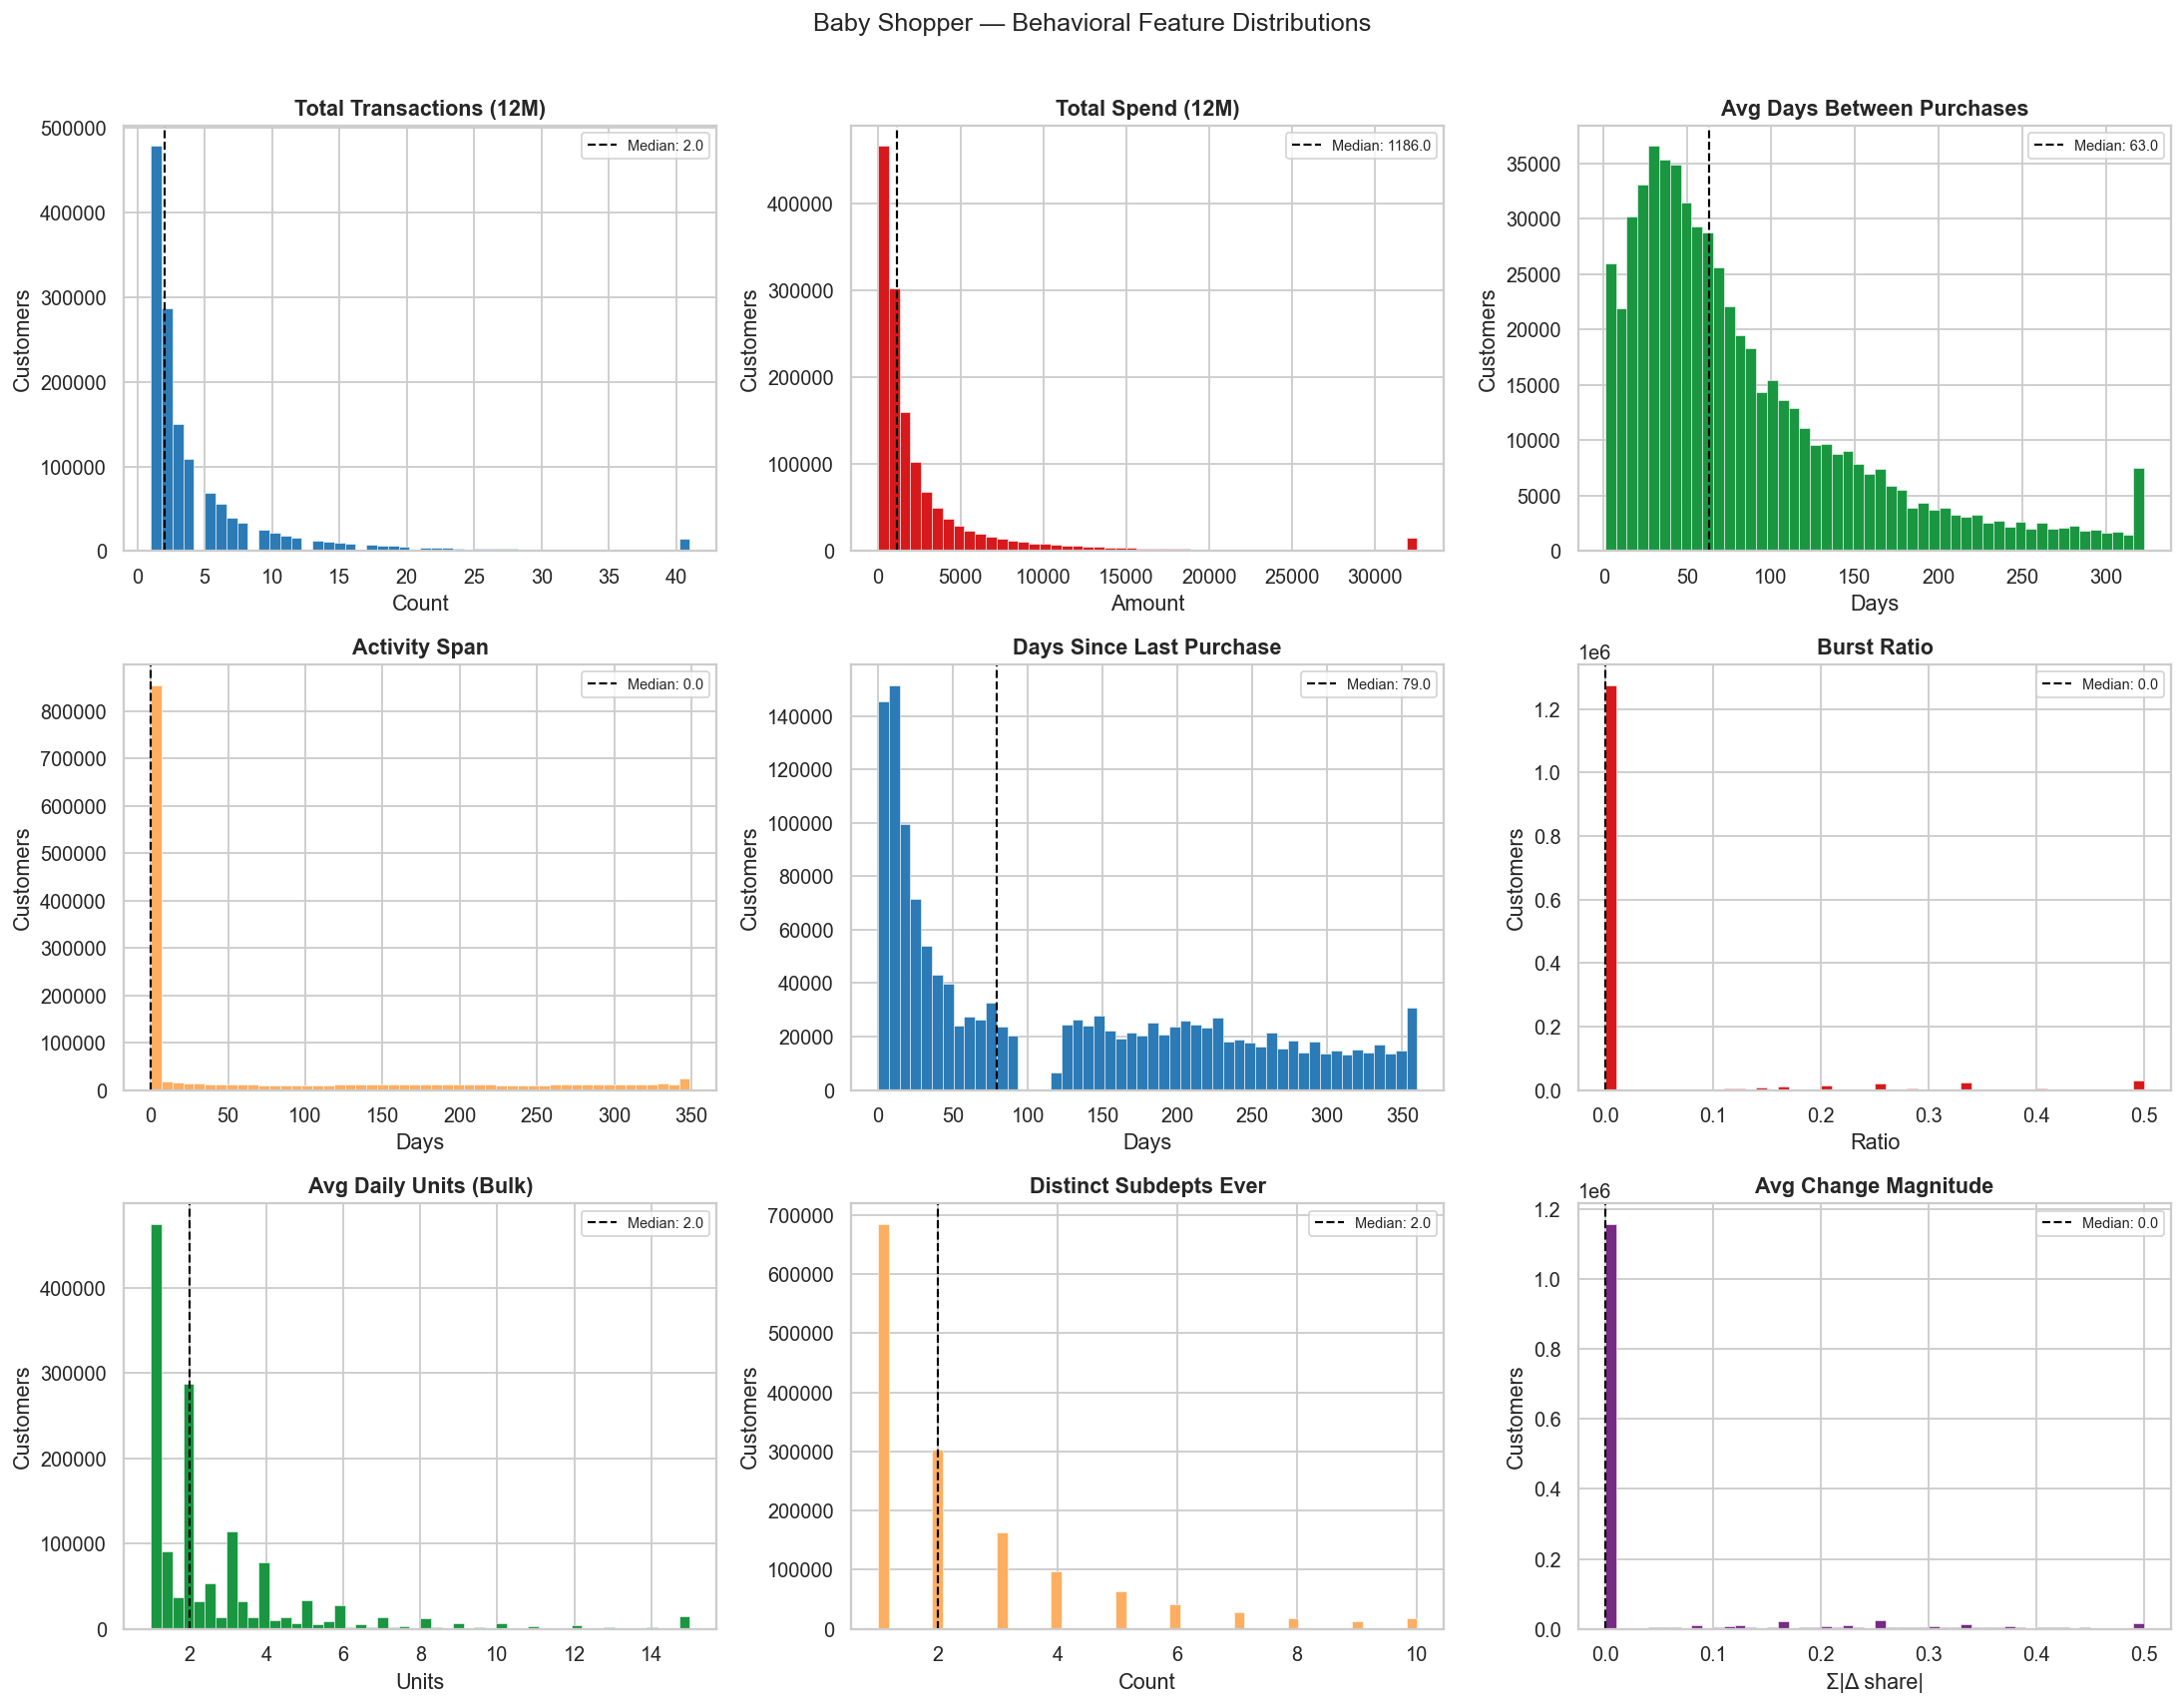

In [20]:
# ── 8.1 Core behavioral distributions ────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.suptitle('Baby Shopper — Behavioral Feature Distributions', fontsize=14, y=1.01)

def hist(ax, series, title, xlabel, color=PALETTE[0], pct=0.99):
    data = series.dropna()
    clip_val = data.quantile(pct)
    ax.hist(data.clip(upper=clip_val), bins=50, color=color,
            edgecolor='white', linewidth=0.3)
    med = data.median()
    ax.axvline(med, color='black', linestyle='--', lw=1.2,
               label=f'Median: {med:.1f}')
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('Customers')
    ax.legend(fontsize=8)

hist(axes[0,0], profile['total_transactions_12m'], 'Total Transactions (12M)', 'Count',      PALETTE[0])
hist(axes[0,1], profile['total_spend_12m'],        'Total Spend (12M)',        'Amount',      PALETTE[1])
hist(axes[0,2], profile['avg_gap_days'],           'Avg Days Between Purchases','Days',       PALETTE[2])
hist(axes[1,0], profile['activity_span_days'],     'Activity Span',            'Days',        PALETTE[3])
hist(axes[1,1], profile['days_since_last_purchase'],'Days Since Last Purchase', 'Days',       PALETTE[0])
hist(axes[1,2], profile['burst_ratio'],            'Burst Ratio',              'Ratio',       PALETTE[1])
hist(axes[2,0], profile['bulk_score'],             'Avg Daily Units (Bulk)',   'Units',       PALETTE[2])
hist(axes[2,1], profile['distinct_subdept_count'], 'Distinct Subdepts Ever',   'Count',       PALETTE[3])
hist(axes[2,2], profile['avg_change_magnitude'],   'Avg Change Magnitude',     'Σ|Δ share|',  PALETTE[4])

plt.tight_layout()
plt.savefig('01_behavioral_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


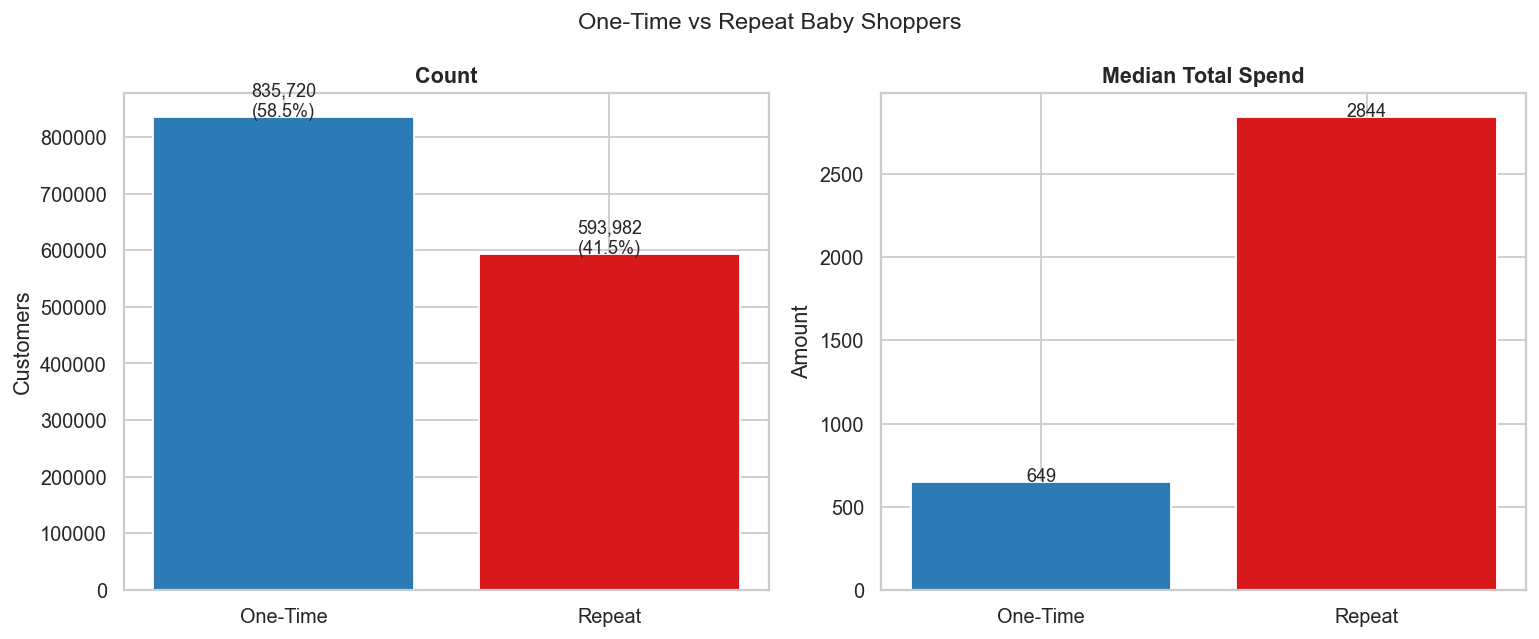

In [21]:
# ── 8.2 Shopper type: one-time vs repeat ─────────────────────────────────────
type_counts = profile['shopper_type'].value_counts()
type_spend  = profile.groupby('shopper_type')['total_spend_12m'].median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('One-Time vs Repeat Baby Shoppers')

ax1.bar(type_counts.index, type_counts.values,
        color=[PALETTE[0], PALETTE[1]], edgecolor='white')
ax1.set_title('Count'); ax1.set_ylabel('Customers')
for i, (cat, val) in enumerate(type_counts.items()):
    ax1.text(i, val + 50, f'{val:,}\n({val/len(profile)*100:.1f}%)',
             ha='center', fontsize=10)

ax2.bar(type_spend.index, type_spend.values,
        color=[PALETTE[0], PALETTE[1]], edgecolor='white')
ax2.set_title('Median Total Spend'); ax2.set_ylabel('Amount')
for i, (cat, val) in enumerate(type_spend.items()):
    ax2.text(i, val + 1, f'{val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('02_shopper_type.png', dpi=150, bbox_inches='tight')
plt.show()


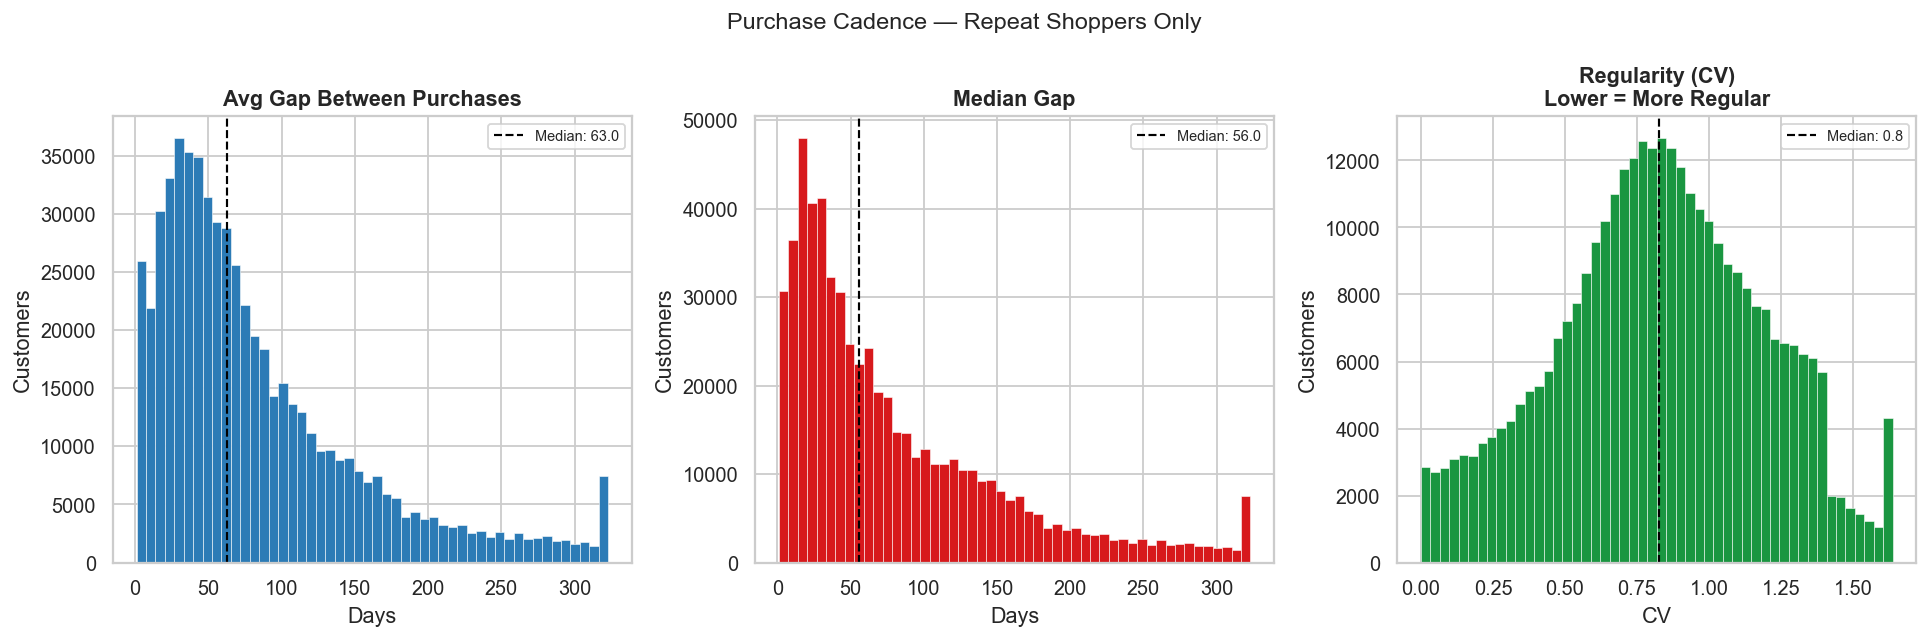

In [22]:
# ── 8.3 Purchase cadence distribution — repeat shoppers only ─────────────────
repeat = profile[profile['shopper_type'] == 'Repeat'].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Purchase Cadence — Repeat Shoppers Only')

hist(axes[0], repeat['avg_gap_days'],    'Avg Gap Between Purchases', 'Days', PALETTE[0])
hist(axes[1], repeat['median_gap_days'], 'Median Gap',                'Days', PALETTE[1])
hist(axes[2], repeat['purchase_regularity_cv'], 'Regularity (CV)\nLower = More Regular',
     'CV', PALETTE[2])

plt.tight_layout()
plt.savefig('03_purchase_cadence.png', dpi=150, bbox_inches='tight')
plt.show()


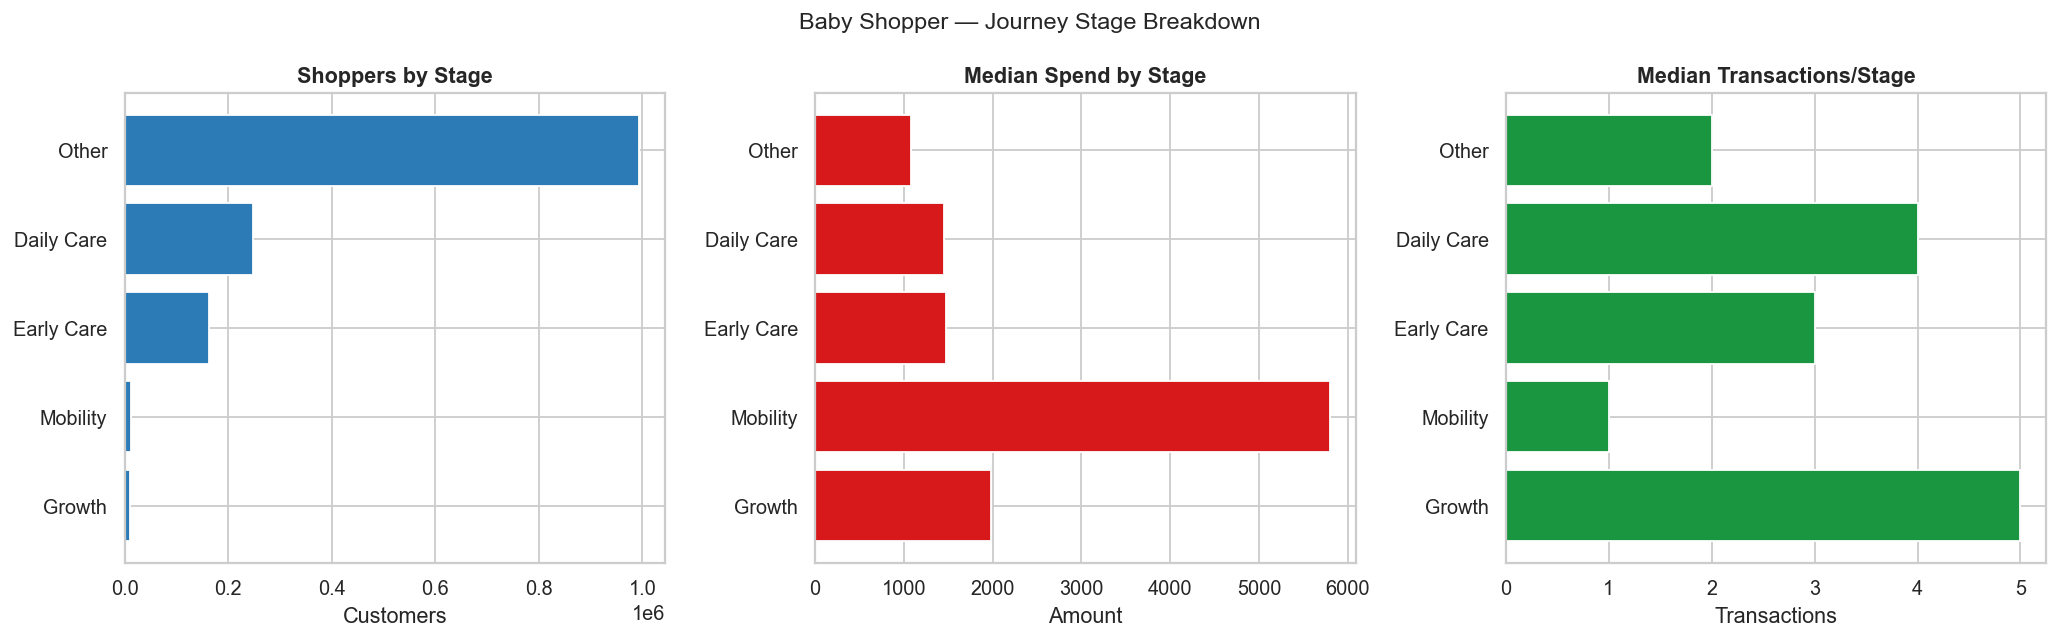

In [23]:
# ── 8.4 Journey stage distribution ───────────────────────────────────────────
stage_counts = profile['journey_stage'].value_counts()
stage_spend  = profile.groupby('journey_stage')['total_spend_12m'].median().reindex(stage_counts.index)
stage_freq   = profile.groupby('journey_stage')['total_transactions_12m'].median().reindex(stage_counts.index)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baby Shopper — Journey Stage Breakdown')

for ax, data, title, xlabel, color in [
    (axes[0], stage_counts,  'Shoppers by Stage',        'Customers',     PALETTE[0]),
    (axes[1], stage_spend,   'Median Spend by Stage',    'Amount',        PALETTE[1]),
    (axes[2], stage_freq,    'Median Transactions/Stage','Transactions',  PALETTE[2]),
]:
    ax.barh(data.index, data.values, color=color, edgecolor='white')
    ax.set_title(title); ax.set_xlabel(xlabel)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('04_journey_stages.png', dpi=150, bbox_inches='tight')
plt.show()


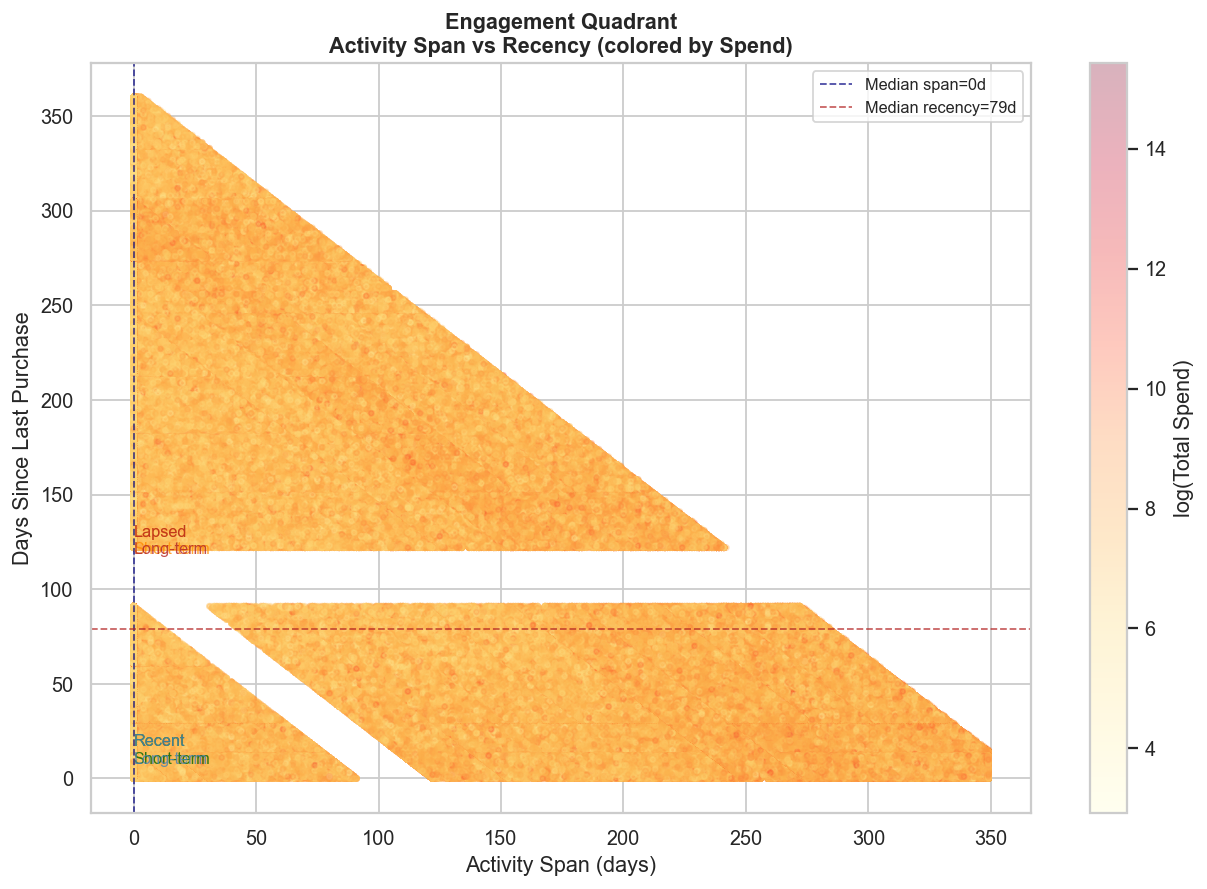

In [24]:
# ── 8.5 Activity span vs recency — engagement quadrant ───────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

span_clip    = profile['activity_span_days'].clip(upper=profile['activity_span_days'].quantile(0.99))
recency_clip = profile['days_since_last_purchase'].clip(upper=profile['days_since_last_purchase'].quantile(0.99))

sc = ax.scatter(
    span_clip, recency_clip,
    c=np.log1p(profile['total_spend_12m']),
    cmap='YlOrRd', alpha=0.3, s=8
)
plt.colorbar(sc, label='log(Total Spend)')

span_med    = span_clip.median()
recency_med = recency_clip.median()
ax.axvline(span_med,    color='navy',  linestyle='--', lw=1, alpha=0.7, label=f'Median span={span_med:.0f}d')
ax.axhline(recency_med, color='firebrick', linestyle='--', lw=1, alpha=0.7, label=f'Median recency={recency_med:.0f}d')

ax.set_title('Engagement Quadrant\nActivity Span vs Recency (colored by Spend)', fontweight='bold')
ax.set_xlabel('Activity Span (days)'); ax.set_ylabel('Days Since Last Purchase')
ax.legend(fontsize=9)

# Quadrant labels
ax.text(span_med*0.1,    recency_med*0.1,  'Recent\nShort-term',   fontsize=9, color='darkgreen',  alpha=0.8)
ax.text(span_med*1.5,    recency_med*0.1,  'Recent\nLong-term',    fontsize=9, color='steelblue',  alpha=0.8)
ax.text(span_med*0.1,    recency_med*1.5,  'Lapsed\nShort-term',   fontsize=9, color='darkorange', alpha=0.8)
ax.text(span_med*1.5,    recency_med*1.5,  'Lapsed\nLong-term',    fontsize=9, color='firebrick',  alpha=0.8)

plt.tight_layout()
plt.savefig('05_engagement_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()


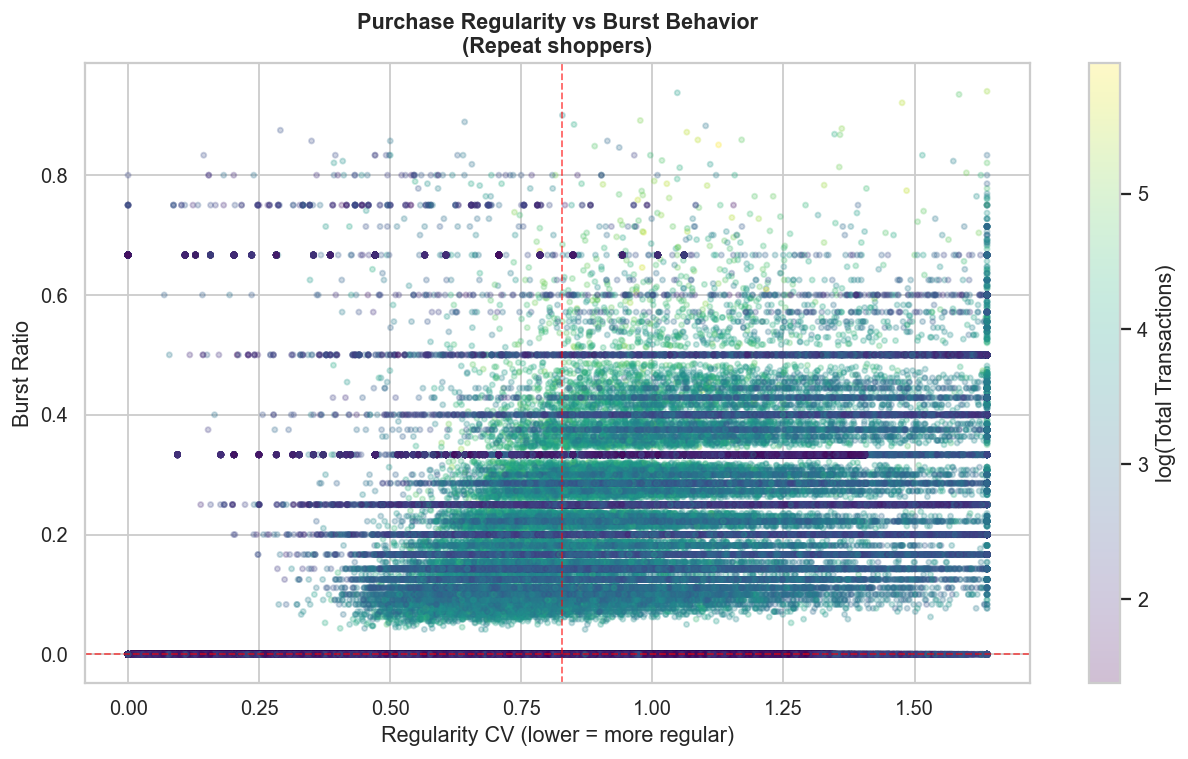

In [25]:
# ── 8.6 Burst vs regularity scatterplot ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    repeat['purchase_regularity_cv'].clip(upper=repeat['purchase_regularity_cv'].quantile(0.99)),
    repeat['burst_ratio'],
    c=np.log1p(repeat['total_transactions_12m']),
    cmap='viridis', alpha=0.25, s=8
)
plt.colorbar(sc, label='log(Total Transactions)')
ax.set_title('Purchase Regularity vs Burst Behavior\n(Repeat shoppers)', fontweight='bold')
ax.set_xlabel('Regularity CV (lower = more regular)')
ax.set_ylabel('Burst Ratio')

ax.axvline(repeat['purchase_regularity_cv'].median(), color='red', linestyle='--', lw=1, alpha=0.6)
ax.axhline(repeat['burst_ratio'].median(),            color='red', linestyle='--', lw=1, alpha=0.6)

plt.tight_layout()
plt.savefig('06_burst_vs_regularity.png', dpi=150, bbox_inches='tight')
plt.show()


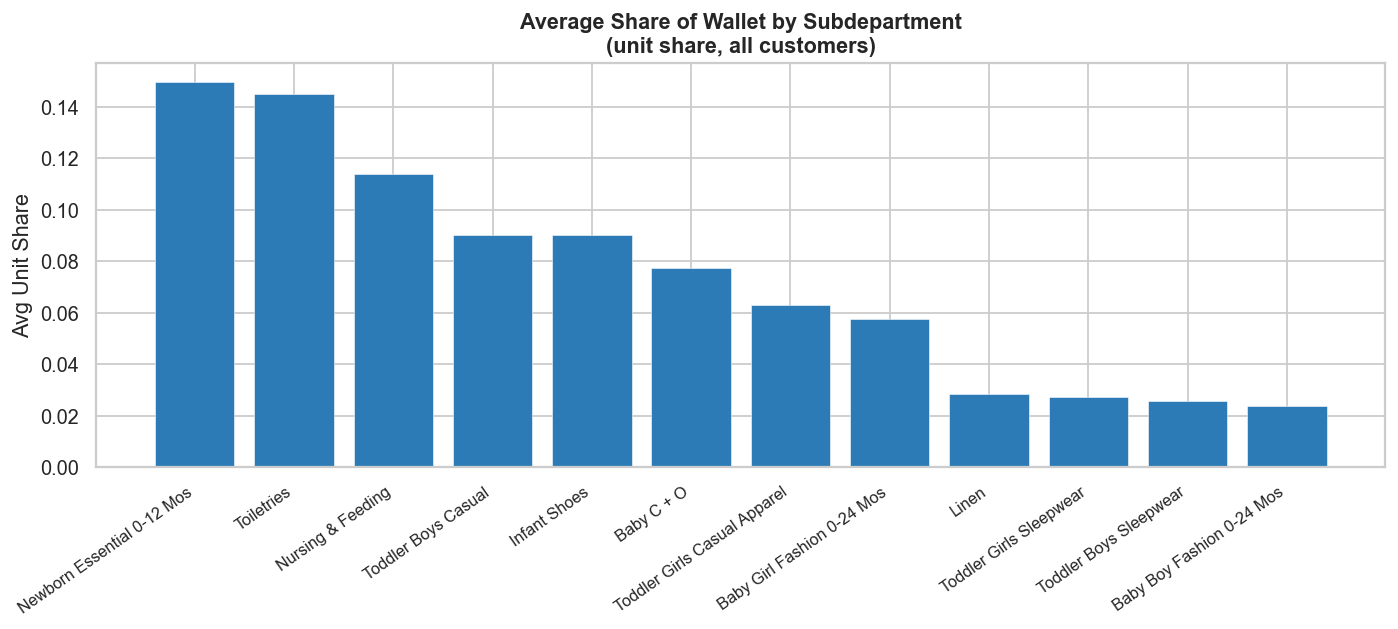

In [26]:
# ── 8.7 Category share of wallet — top subdepts ───────────────────────────────
sow_cols = [c for c in profile.columns if c.startswith('sow__')]
sow_means = (
    profile[sow_cols].mean()
                     .sort_values(ascending=False)
                     .head(12)
)
sow_means.index = [c.replace('sow__','').replace('_',' ').title() for c in sow_means.index]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(sow_means.index, sow_means.values,
       color=PALETTE[0], edgecolor='white', linewidth=0.3)
ax.set_title('Average Share of Wallet by Subdepartment\n(unit share, all customers)', fontweight='bold')
ax.set_ylabel('Avg Unit Share')
ax.set_xticklabels(sow_means.index, rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('07_share_of_wallet.png', dpi=150, bbox_inches='tight')
plt.show()


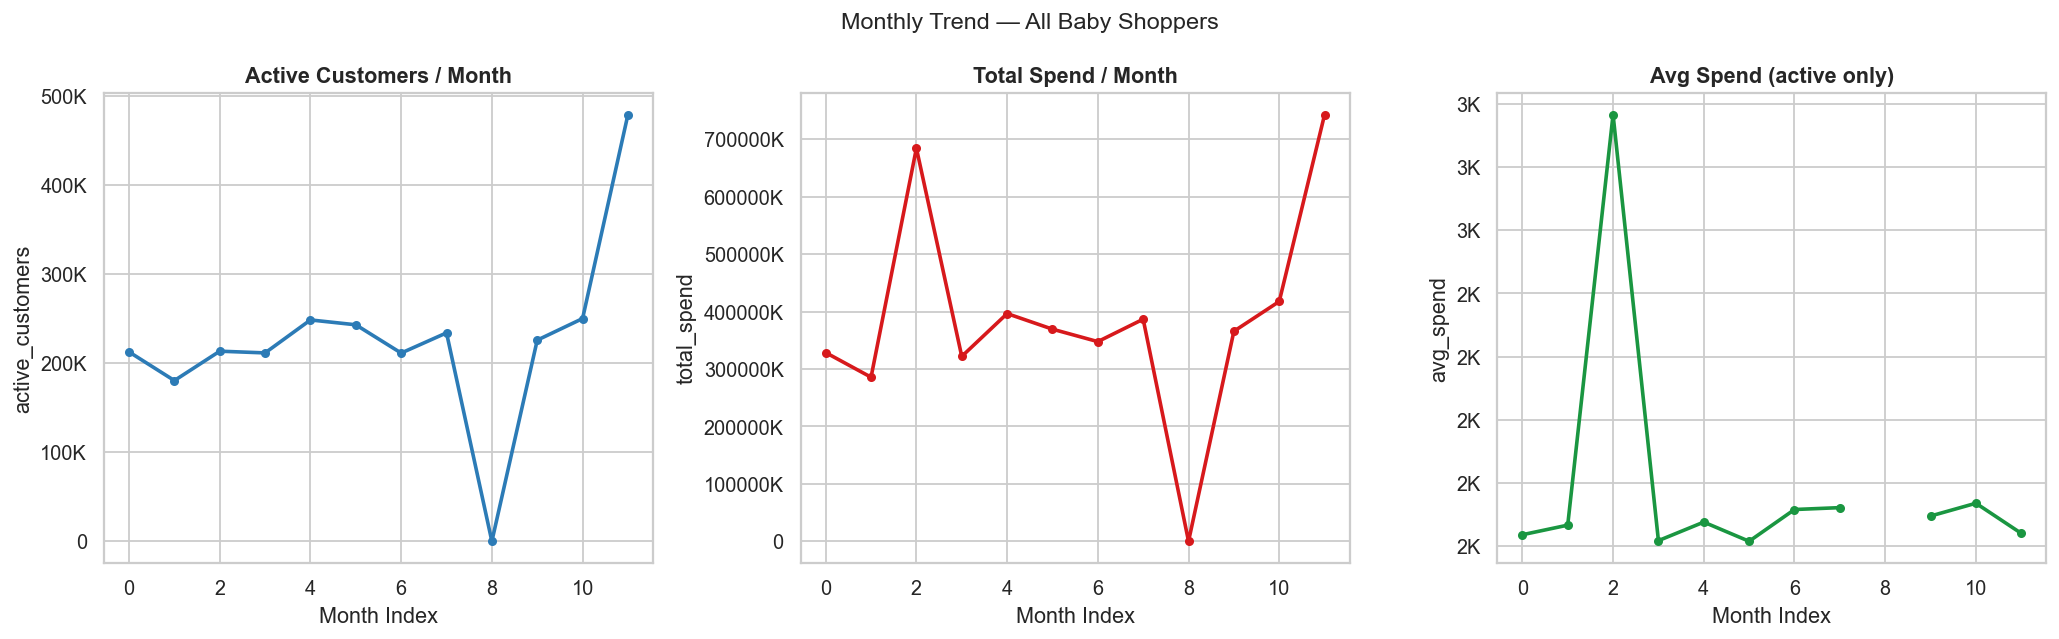

In [27]:
# ── 8.8 Monthly panel trends ─────────────────────────────────────────────────
# avg spend on active months only: pre-filter, then merge
active_panel = panel[panel['is_active'] == 1]
avg_spend_monthly = (
    active_panel.groupby('year_month')['total_spend']
                .mean()
                .rename('avg_spend')
                .reset_index()
)
panel_monthly = (
    panel.groupby('year_month')
         .agg(
             active_customers = ('is_active',    'sum'),
             total_spend      = ('total_spend',  'sum'),
         )
         .reset_index()
         .merge(avg_spend_monthly, on='year_month', how='left')
)
months_idx = range(len(panel_monthly))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Monthly Trend — All Baby Shoppers')

def fmt_k(x, _):
    return f'{x/1e3:.0f}K' if x >= 1000 else f'{x:.0f}'

for ax, col, title, color in [
    (axes[0], 'active_customers', 'Active Customers / Month', PALETTE[0]),
    (axes[1], 'total_spend',      'Total Spend / Month',      PALETTE[1]),
    (axes[2], 'avg_spend',        'Avg Spend (active only)',  PALETTE[2]),
]:
    ax.plot(months_idx, panel_monthly[col], 'o-', color=color, linewidth=2, markersize=4)
    ax.set_title(title); ax.set_xlabel('Month Index'); ax.set_ylabel(col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

plt.tight_layout()
plt.savefig('08_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Behavioral Clustering

Grouping shoppers by **how they shop**, not what they buy.

Clustering features are drawn directly from the spec's behavioral dimensions:
frequency, cadence, span, burst, bulk, breadth, recency, and spend.


In [28]:
# ── 9.1 Define clustering features ───────────────────────────────────────────
CLUSTER_FEATURES = [
    'total_transactions_12m',    # frequency
    'total_spend_12m',           # spend level
    'avg_gap_days',              # purchase cadence
    'activity_span_days',        # engagement duration
    'days_since_last_purchase',  # recency
    'burst_ratio',               # burst behavior
    'bulk_score',                # bulk purchasing
    'distinct_subdept_count',    # category breadth
    'purchase_regularity_cv',    # regular vs erratic
    'engagement_density',        # active months / possible months
]

cluster_df = profile[['customer_id','shopper_type'] + CLUSTER_FEATURES].dropna(
    subset=CLUSTER_FEATURES
).copy()

# Clip outliers (p1–p99) before scaling
for col in CLUSTER_FEATURES:
    lo, hi = cluster_df[col].quantile([0.01, 0.99])
    cluster_df[col] = cluster_df[col].clip(lo, hi)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[CLUSTER_FEATURES])
print(f"Clustering dataset: {cluster_df.shape[0]:,} customers, {len(CLUSTER_FEATURES)} features")


Clustering dataset: 334,515 customers, 10 features


  k=2  inertia=2,485,342  silhouette=0.2971
  k=3  inertia=2,066,011  silhouette=0.2211
  k=4  inertia=1,838,083  silhouette=0.1969
  k=5  inertia=1,649,540  silhouette=0.2078
  k=6  inertia=1,515,460  silhouette=0.2147
  k=7  inertia=1,423,551  silhouette=0.2002
  k=8  inertia=1,342,301  silhouette=0.1804


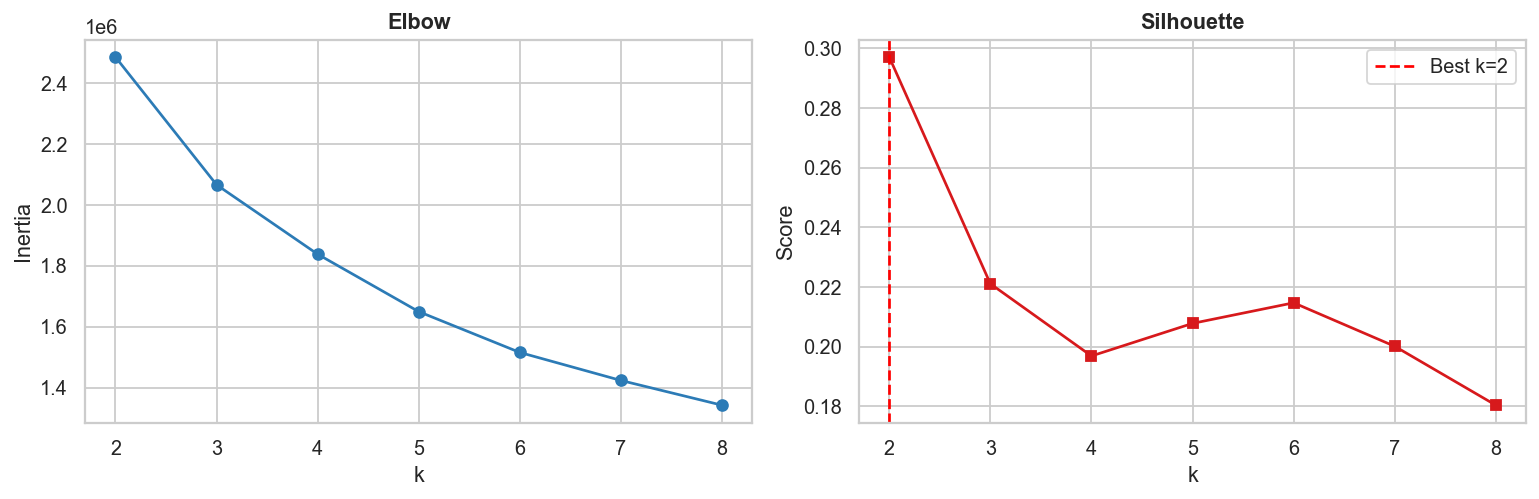


Statistically optimal k = 2


In [29]:
# ── 9.2 Optimal k — elbow + silhouette ───────────────────────────────────────
K_RANGE      = range(2, 9)
inertias     = []
silhouettes  = []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, lbl, sample_size=min(5000, len(X_scaled)),
                           random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

best_k = list(K_RANGE)[np.argmax(silhouettes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias,    'o-', color=PALETTE[0]); ax1.set_title('Elbow'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax2.plot(list(K_RANGE), silhouettes, 's-', color=PALETTE[1]); ax2.set_title('Silhouette'); ax2.set_xlabel('k'); ax2.set_ylabel('Score')
ax2.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}'); ax2.legend()
plt.tight_layout()
plt.savefig('09_cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nStatistically optimal k = {best_k}")


In [30]:
# ── 9.3 Fit final model ───────────────────────────────────────────────────────
# Set K_FINAL = best_k, or override if a different k tells a clearer story
K_FINAL  = best_k

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)
profile = profile.merge(cluster_df[['customer_id','cluster']], on='customer_id', how='left')

print("Cluster distribution:")
print(profile['cluster'].value_counts().sort_index())


Cluster distribution:
cluster
0.000     79797
1.000    254718
Name: count, dtype: int64


In [31]:
# ── 9.4 Cluster centroids ─────────────────────────────────────────────────────
centroids = (
    profile.dropna(subset=['cluster'])
           .groupby('cluster')[CLUSTER_FEATURES]
           .median()
)
centroids['n']   = profile['cluster'].value_counts().sort_index()
centroids['pct'] = (centroids['n'] / len(profile) * 100).round(1)

print("=== Cluster Centroids (median) ===")
centroids.T


=== Cluster Centroids (median) ===


cluster,0.000,1.000
total_transactions_12m,25.000,7.000
total_spend_12m,15773.000,3438.000
avg_gap_days,33.500,65.500
activity_span_days,304.000,211.000
days_since_last_purchase,15.000,32.000
burst_ratio,0.158,0.000
bulk_score,3.900,2.250
distinct_subdept_count,8.000,4.000
purchase_regularity_cv,0.890,0.798
engagement_density,0.500,0.250


In [32]:
# ── 9.5 Auto-name clusters from centroid profile ─────────────────────────────
# Review centroids above and rename as needed
CLUSTER_NAMES = {}
for c in sorted(profile['cluster'].dropna().unique()):
    c = int(c)
    freq    = centroids.loc[c, 'total_transactions_12m']
    gap     = centroids.loc[c, 'avg_gap_days']
    span    = centroids.loc[c, 'activity_span_days']
    recency = centroids.loc[c, 'days_since_last_purchase']
    burst   = centroids.loc[c, 'burst_ratio']
    bulk    = centroids.loc[c, 'bulk_score']
    density = centroids.loc[c, 'engagement_density']

    med_freq    = centroids['total_transactions_12m'].median()
    med_recency = centroids['days_since_last_purchase'].median()
    med_burst   = centroids['burst_ratio'].median()
    med_bulk    = centroids['bulk_score'].median()

    if recency > med_recency * 1.5:
        name = 'Lapsed Shoppers'
    elif freq <= 1:
        name = 'One-and-Done'
    elif burst > med_burst * 1.4 and bulk > med_bulk * 1.3:
        name = 'Stockpilers'
    elif burst > med_burst * 1.4:
        name = 'Burst Shoppers'
    elif freq > med_freq * 1.3 and gap < centroids['avg_gap_days'].median():
        name = 'High-Frequency Regulars'
    elif density > centroids['engagement_density'].median():
        name = 'Consistent Engagers'
    else:
        name = 'Moderate Buyers'

    CLUSTER_NAMES[c] = name
    print(f"Cluster {c} ({centroids.loc[c,'pct']:.1f}%) → '{name}'")

profile['segment'] = profile['cluster'].map(CLUSTER_NAMES)


Cluster 0 (5.6%) → 'Burst Shoppers'
Cluster 1 (17.8%) → 'Moderate Buyers'


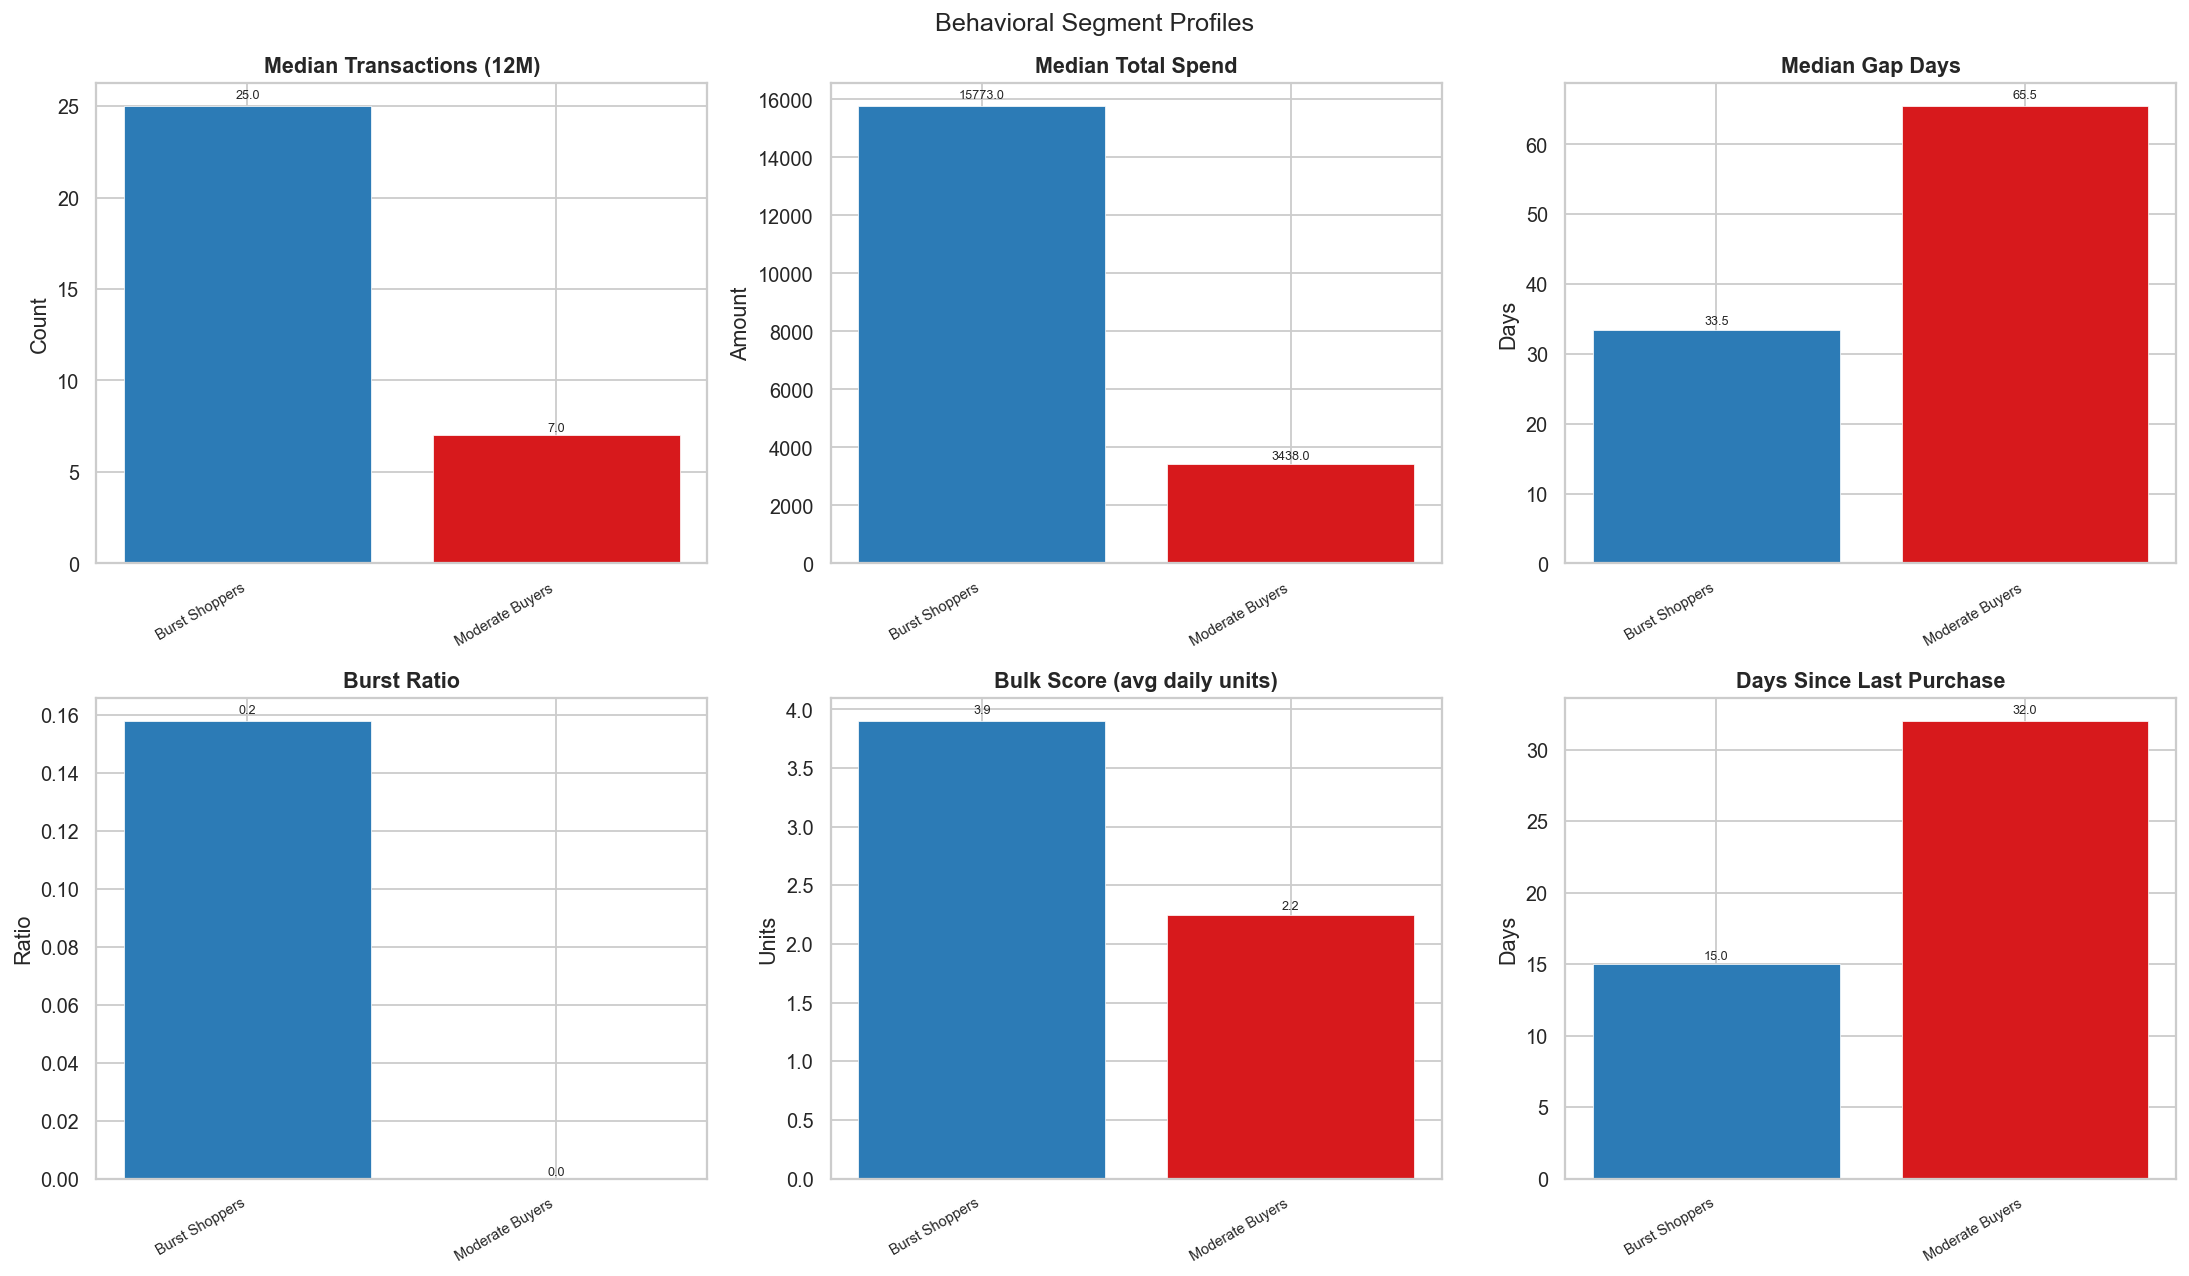

In [33]:
# ── 9.6 Segment comparison — bar charts ──────────────────────────────────────
seg_order = (
    profile.groupby('segment')['total_transactions_12m']
           .median().sort_values(ascending=False).index.tolist()
)

metrics = [
    ('total_transactions_12m',  'Median Transactions (12M)', 'Count'),
    ('total_spend_12m',         'Median Total Spend',        'Amount'),
    ('avg_gap_days',            'Median Gap Days',           'Days'),
    ('burst_ratio',             'Burst Ratio',               'Ratio'),
    ('bulk_score',              'Bulk Score (avg daily units)','Units'),
    ('days_since_last_purchase','Days Since Last Purchase',  'Days'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Behavioral Segment Profiles', fontsize=14)

for ax, (col, title, ylabel) in zip(axes.flatten(), metrics):
    vals = profile.groupby('segment')[col].median().reindex(seg_order)
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(vals))]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('10_segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


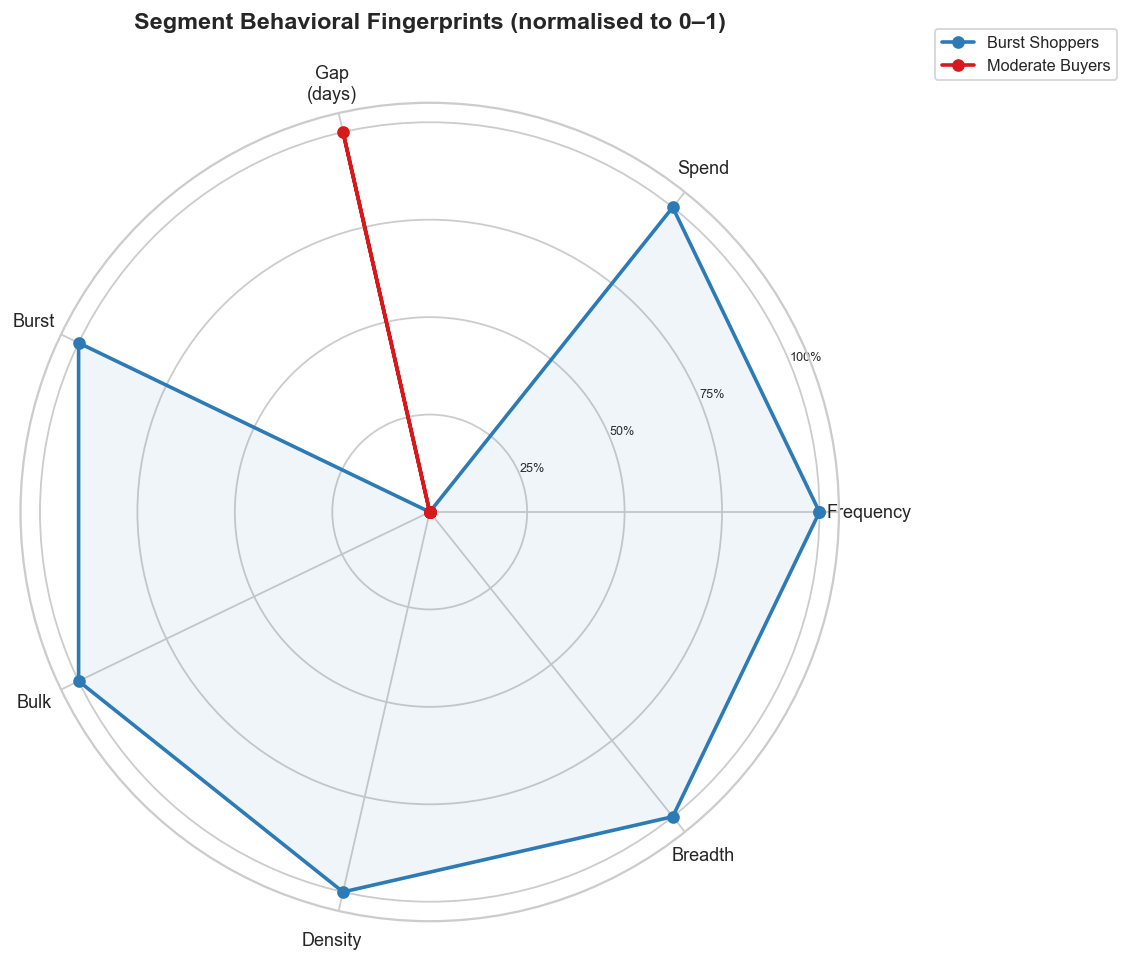

In [39]:
# ── 9.7 Radar chart — segment behavioral fingerprints ────────────────────────
radar_features = [
    'total_transactions_12m','total_spend_12m','avg_gap_days',
    'burst_ratio','bulk_score','engagement_density','distinct_subdept_count'
]
radar_labels = ['Frequency','Spend','Gap\n(days)','Burst','Bulk','Density','Breadth']

seg_radar = (
    profile.dropna(subset=['segment'])
           .groupby('segment')[radar_features].median()
)
seg_norm = (seg_radar - seg_radar.min()) / (seg_radar.max() - seg_radar.min() + 1e-9)

N      = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for i, (seg, row) in enumerate(seg_norm.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    color = PALETTE[i % len(PALETTE)]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=seg)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7)
ax.set_title('Segment Behavioral Fingerprints' +
             ' (normalised to 0–1)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('11_segment_radar.png', dpi=150, bbox_inches='tight')
plt.show()


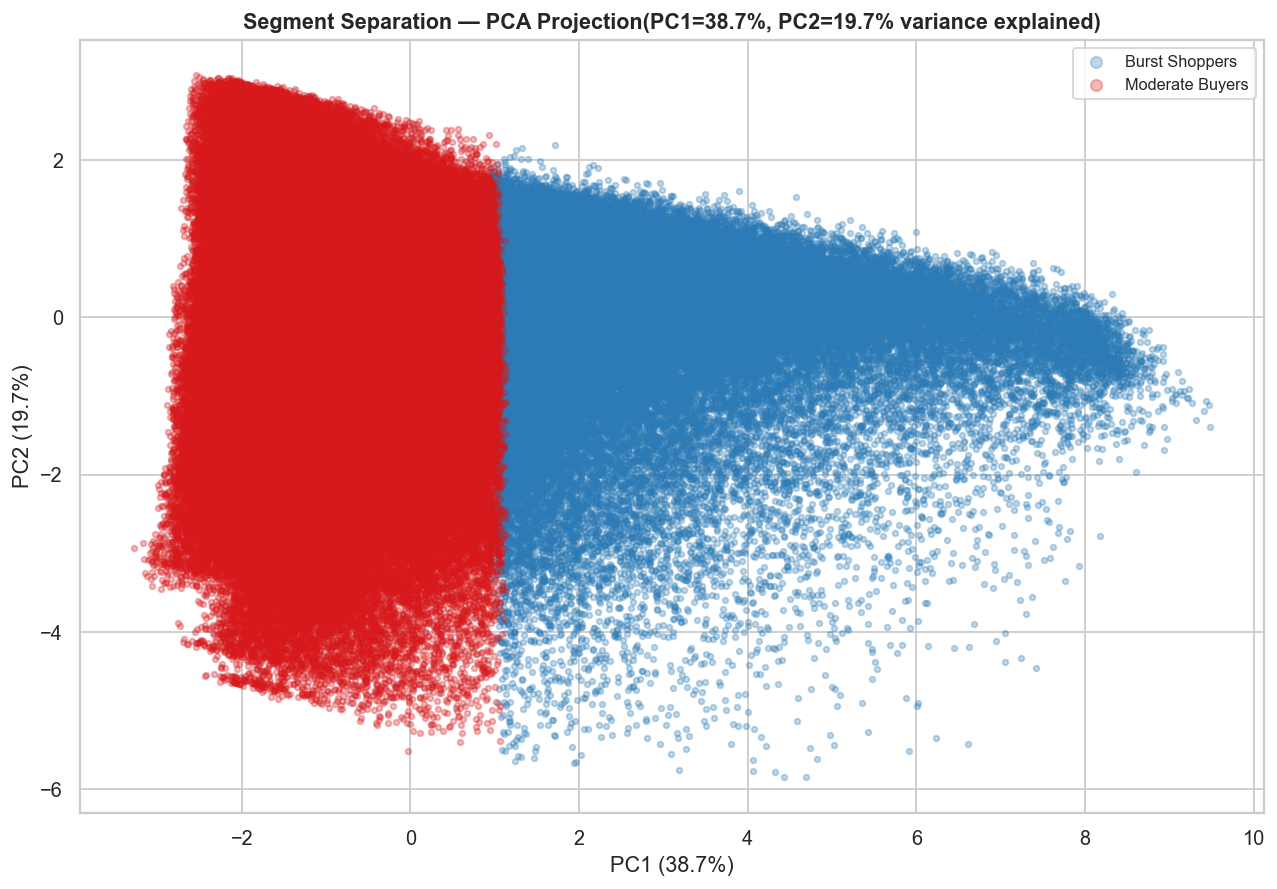

In [41]:
# ── 9.8 PCA scatter — cluster separation ─────────────────────────────────────
pca     = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca   = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

pca_df = cluster_df[['customer_id','cluster']].copy()
pca_df['pc1'] = X_pca[:, 0]
pca_df['pc2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(pca_df['cluster'].unique()):
    mask = pca_df['cluster'] == c
    ax.scatter(pca_df.loc[mask,'pc1'], pca_df.loc[mask,'pc2'],
               label=CLUSTER_NAMES.get(int(c), f'Cluster {c}'),
               alpha=0.3, s=10, color=PALETTE[int(c) % len(PALETTE)])

ax.set_title(f'Segment Separation — PCA Projection'
             f'(PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}% variance explained)',
             fontweight='bold')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.savefig('12_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Category Transition Signals
*(Descriptive only — prediction is Phase 2)*

How do baby shoppers move between subdepartments over time?  
This transition view is the direct input for Phase 2 lifecycle modeling.


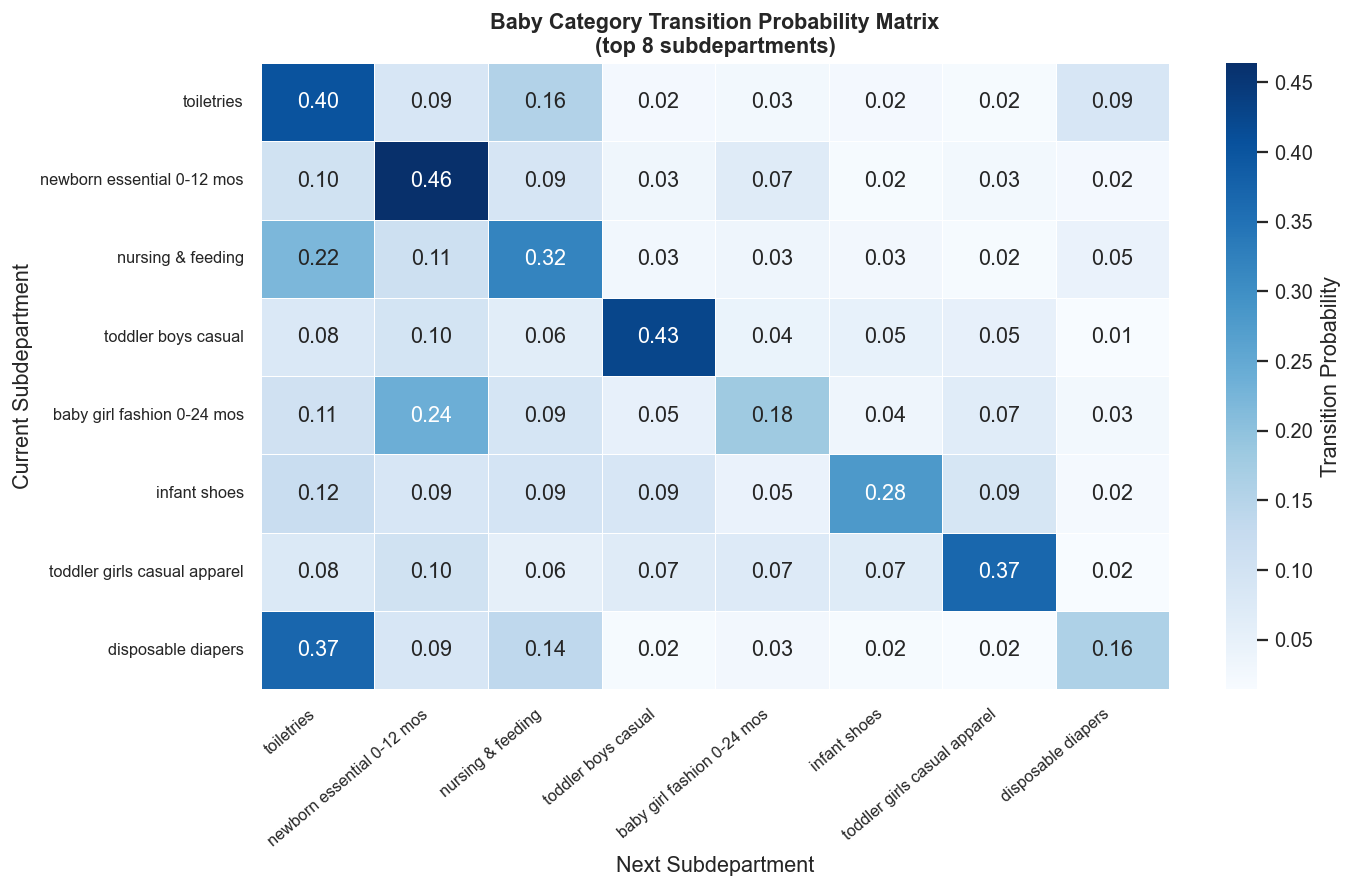

In [42]:
# ── 10.1 Transition probability matrix ────────────────────────────────────────
df_sorted = df.sort_values(['customer_id', 'date'])
df_sorted['next_subdept'] = df_sorted.groupby('customer_id')['subdepartment_cleaned'].shift(-1)

transitions = (
    df_sorted.dropna(subset=['next_subdept'])
             .groupby(['subdepartment_cleaned', 'next_subdept'])
             .size()
             .reset_index(name='count')
)
# Probability = count / row total per from-subdept — vectorised divide
from_totals = transitions.groupby('subdepartment_cleaned')['count'].sum().rename('from_total')
transitions = transitions.join(from_totals, on='subdepartment_cleaned')
transitions['prob'] = transitions['count'] / transitions['from_total']
transitions = transitions.drop(columns='from_total')

top_subdepts = df['subdepartment_cleaned'].value_counts().head(8).index.tolist()
hm_data = (
    transitions[
        transitions['subdepartment_cleaned'].isin(top_subdepts) &
        transitions['next_subdept'].isin(top_subdepts)
    ]
    .pivot(index='subdepartment_cleaned', columns='next_subdept', values='prob')
    .fillna(0)
    .reindex(index=top_subdepts, columns=top_subdepts, fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(hm_data, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Transition Probability'})
ax.set_title('Baby Category Transition Probability Matrix\n(top 8 subdepartments)',
             fontweight='bold')
ax.set_xlabel('Next Subdepartment'); ax.set_ylabel('Current Subdepartment')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('13_transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


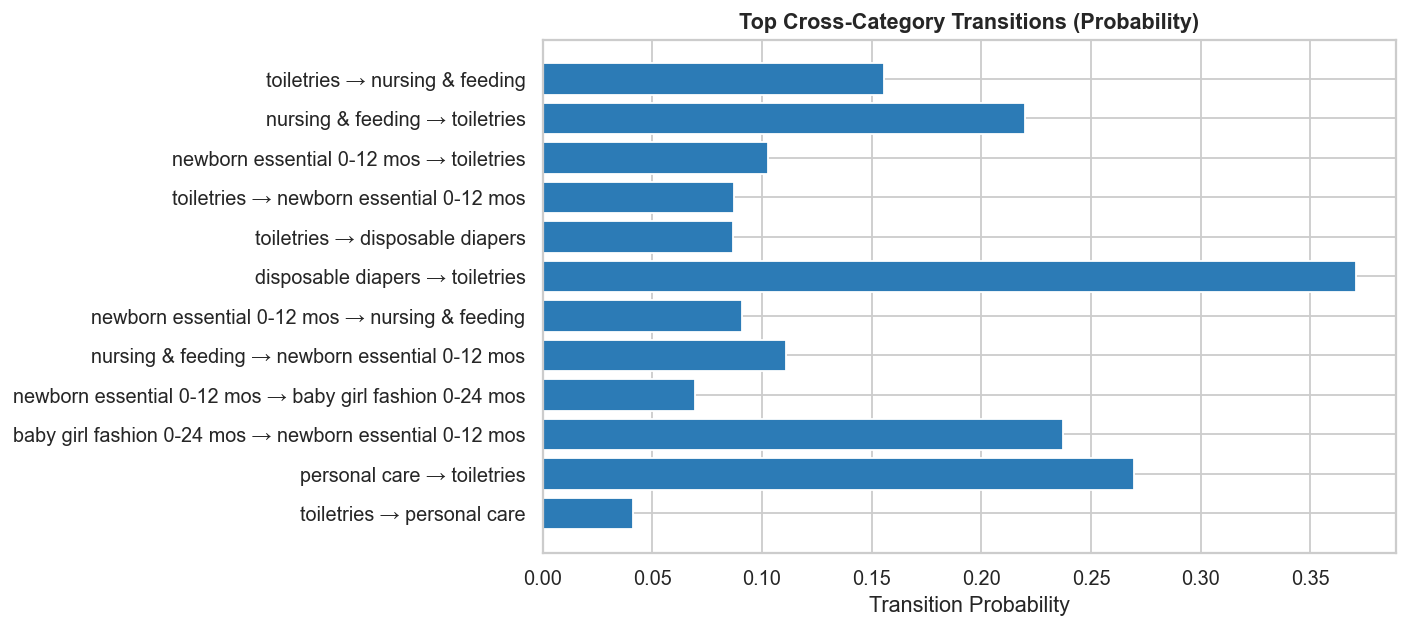

In [43]:
# ── 10.2 Top cross-category transitions ──────────────────────────────────────
cross = (
    transitions[transitions['subdepartment_cleaned'] != transitions['next_subdept']]
    .sort_values('count', ascending=False).head(12)
)
cross['label'] = cross['subdepartment_cleaned'] + ' → ' + cross['next_subdept']

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(cross['label'], cross['prob'], color=PALETTE[0], edgecolor='white')
ax.set_title('Top Cross-Category Transitions (Probability)', fontweight='bold')
ax.set_xlabel('Transition Probability'); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('14_top_transitions.png', dpi=150, bbox_inches='tight')
plt.show()


In [44]:
# ── 10.3 Transition patterns by segment ──────────────────────────────────────
df_seg = df.merge(profile[['customer_id', 'segment']], on='customer_id', how='left')
df_seg = df_seg.sort_values(['customer_id', 'date'])
df_seg['next_subdept'] = df_seg.groupby('customer_id')['subdepartment_cleaned'].shift(-1)

seg_transitions = (
    df_seg.dropna(subset=['next_subdept', 'segment'])
          .groupby(['segment', 'subdepartment_cleaned', 'next_subdept'])
          .size()
          .reset_index(name='count')
)

# Vectorised probability: join group totals then divide
seg_from_totals = (
    seg_transitions.groupby(['segment', 'subdepartment_cleaned'])['count']
                   .sum()
                   .rename('from_total')
                   .reset_index()
)
seg_transitions = seg_transitions.merge(seg_from_totals, on=['segment', 'subdepartment_cleaned'])
seg_transitions['prob'] = seg_transitions['count'] / seg_transitions['from_total']
seg_transitions = seg_transitions.drop(columns='from_total')

# Top cross-category exit per segment × subdept
top_exits = (
    seg_transitions[seg_transitions['subdepartment_cleaned'] != seg_transitions['next_subdept']]
    .sort_values('prob', ascending=False)
    .groupby(['segment', 'subdepartment_cleaned'])
    .first()
    .reset_index()[['segment', 'subdepartment_cleaned', 'next_subdept', 'prob']]
    .rename(columns={'subdepartment_cleaned': 'from', 'next_subdept': 'to'})
)
print("Most probable cross-category move per segment × subdept:")
print(top_exits.sort_values(['segment', 'prob'], ascending=[True, False]).to_string(index=False))


Most probable cross-category move per segment × subdept:
        segment                            from                           to  prob
 Burst Shoppers                     furnishings                   toiletries 0.750
 Burst Shoppers                 branded apparel           disposable diapers 0.429
 Burst Shoppers                         diapers                   toiletries 0.397
 Burst Shoppers              disposable diapers                   toiletries 0.380
 Burst Shoppers                   personal care                   toiletries 0.288
 Burst Shoppers            food and supplements                   toiletries 0.269
 Burst Shoppers               nursing & feeding                   toiletries 0.250
 Burst Shoppers                      baby c + o                   toiletries 0.241
 Burst Shoppers      baby girl fashion 0-24 mos   newborn essential 0-12 mos 0.230
 Burst Shoppers                           linen   newborn essential 0-12 mos 0.225
 Burst Shoppers               

---
## 11. Outputs

In [45]:
# ── 11.1 Master profile table ─────────────────────────────────────────────────
OUTPUT_COLS = [
    'customer_id', 'gcr_persistent_id',
    # Temporal
    'total_transactions_12m', 'total_units_12m', 'total_spend_12m',
    'active_months', 'activity_span_days', 'engagement_density',
    'avg_gap_days', 'median_gap_days', 'std_gap_days', 'purchase_regularity_cv',
    'days_since_last_purchase', 'days_to_second_purchase',
    'is_one_time_buyer', 'shopper_type',
    # Spend
    'avg_monthly_spend', 'avg_spend_per_visit', 'max_monthly_spend', 'spend_volatility_avg',
    # Burst
    'burst_count', 'burst_ratio', 'burst_avg_gap',
    # Bulk
    'bulk_score', 'is_bulk', 'bulk_day_count', 'max_day_units',
    # Category
    'top_subdept', 'top_subdept_share', 'distinct_subdept_count',
    'avg_new_subdept_per_month', 'avg_change_magnitude', 'journey_stage',
    # Segments
    'cluster', 'segment',
]
# Add share of wallet columns
OUTPUT_COLS += [c for c in profile.columns if c.startswith('sow__')]
OUTPUT_COLS  = [c for c in OUTPUT_COLS if c in profile.columns]

# Recover gcr_persistent_id
id_map = df[['customer_id','gcr_persistent_id']].drop_duplicates()
output = profile[OUTPUT_COLS].merge(id_map, on='customer_id', how='left')          if 'gcr_persistent_id' not in profile.columns else profile[OUTPUT_COLS]

output.to_parquet('baby_shopper_profiles_phase1.parquet', index=False)
output.to_csv('baby_shopper_profiles_phase1.csv', index=False)
print(f"Saved: baby_shopper_profiles_phase1.parquet")
print(f"  {output.shape[0]:,} customers × {output.shape[1]} features")


Saved: baby_shopper_profiles_phase1.parquet
  1,429,702 customers × 61 features


In [46]:
# ── 11.2 Segment summary card ─────────────────────────────────────────────────
seg_card = (
    profile.dropna(subset=['segment'])
           .groupby('segment')
           .agg(
               n_customers         = ('customer_id',             'count'),
               median_transactions = ('total_transactions_12m',  'median'),
               median_spend        = ('total_spend_12m',         'median'),
               median_gap_days     = ('avg_gap_days',            'median'),
               median_span_days    = ('activity_span_days',      'median'),
               bulk_rate           = ('is_bulk',                 'mean'),
               median_burst_ratio  = ('burst_ratio',             'median'),
               median_recency      = ('days_since_last_purchase', 'median'),
           )
)

# Post-agg formatting — no lambda needed
seg_card['pct_of_base'] = (seg_card['n_customers'] / len(profile) * 100).round(1).astype(str) + '%'
seg_card['pct_bulk']    = (seg_card['bulk_rate'] * 100).round(1).astype(str) + '%'
seg_card = seg_card.drop(columns='bulk_rate')

# Top journey stage per segment — idxmax on a crosstab (fully vectorised)
stage_counts = pd.crosstab(profile['segment'], profile['journey_stage'])
seg_card['top_stage'] = stage_counts.idxmax(axis=1)

seg_card.to_csv('segment_summary_phase1.csv')
print("Saved: segment_summary_phase1.csv\n")
print("=== Segment Summary ===")
seg_card.T


Saved: segment_summary_phase1.csv

=== Segment Summary ===


segment,Burst Shoppers,Moderate Buyers
n_customers,79797,254718
median_transactions,25.000,7.000
median_spend,15773.000,3438.000
median_gap_days,33.500,65.500
median_span_days,304.000,211.000
median_burst_ratio,0.158,0.000
median_recency,15.000,32.000
pct_of_base,5.6%,17.8%
pct_bulk,85.4%,29.6%
top_stage,Daily Care,Other


In [47]:
# ── 11.3 Monthly panel ────────────────────────────────────────────────────────
panel.to_parquet('baby_shopper_panel_monthly.parquet', index=False)
print("Saved: baby_shopper_panel_monthly.parquet")
print(f"  {panel.shape[0]:,} rows (customer × month)")

print("\n=== Phase 1 Complete ===")
print("Phase 2 inputs ready:")
print("  cluster / segment label per customer")
print("  category transition matrix (Section 10)")
print("  monthly panel with delta features (Section 4)")
print("  journey stage per customer")


Saved: baby_shopper_panel_monthly.parquet
  17,156,424 rows (customer × month)

=== Phase 1 Complete ===
Phase 2 inputs ready:
  cluster / segment label per customer
  category transition matrix (Section 10)
  monthly panel with delta features (Section 4)
  journey stage per customer
